# Rooster
# 2. Data Understanding

This notebook continues from `1. Data preparation`. It uses the cleaned datasets exported in that
notebook (`rooster_cleaned.xlsx`) to develop an understanding of Rooster's customer retention
performance.

The business scenario is **customer retention improvement to increase lifetime value**. The purpose
of this notebook is therefore to describe *who* returns to Rooster, *how much* they are worth, and
*which customer characteristics are associated with returning* — so that these findings can inform
both the recommendations and the predictive model developed in the next notebook.

The data understanding process includes:
- Establishing the unit of analysis and the measurement rules used throughout the analysis
- Diagnosing order coverage and observation-window limitations in the supplied extract
- Constructing a customer-level analysis table
- Calculating summary statistics for the key retention and value variables
- Visualising the distribution of customer value and purchase frequency
- Segmenting customers to identify meaningful differences between groups
- Testing whether the observed group differences are statistically significant
- Investigating outliers and unusual patterns
- Running sensitivity checks against the data limitations identified
- Exporting a customer-level feature table for predictive modelling

## 2.1 Setup and Data Import

The cleaned datasets produced in notebook 1 are loaded. No changes are made to the cleaning
decisions taken in that notebook. Any additional treatment applied here is analysis-level only
(for example, grouping very small categories for readability) and is not written back to the
cleaned data.

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.stats.api as sms
from scipy import stats

In [2]:
# format figures for display in Canvas
sns.set_theme(style="white", rc={"figure.figsize": (12, 6)})
sns.set_context("notebook", font_scale=1.25, rc={"lines.linewidth": 2.5})

# display options
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

In [3]:
# Load the cleaned datasets exported from notebook 1
CLEANED_PATH = 'rooster_cleaned.xlsx'

customers = pd.read_excel(CLEANED_PATH, sheet_name='customers_cleaned')
orders = pd.read_excel(CLEANED_PATH, sheet_name='orders_cleaned')
orderlines = pd.read_excel(CLEANED_PATH, sheet_name='orderlines_cleaned')
products = pd.read_excel(CLEANED_PATH, sheet_name='products_cleaned')

In [4]:
# Confirm the dimensions of the cleaned data
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Orderlines:", orderlines.shape)
print("Products:", products.shape)

Customers: (6556, 9)
Orders: (8000, 27)
Orderlines: (21753, 14)
Products: (381, 13)


In [5]:
# The analysis cut-off is the last order date in the extract.
# All recency and observation-window calculations are measured against this date.
ANALYSIS_CUTOFF = orders['order_date'].max()

print("First order date:", orders['order_date'].min().date())
print("Last order date: ", ANALYSIS_CUTOFF.date())
print("Observation period:", (ANALYSIS_CUTOFF - orders['order_date'].min()).days, "days")

First order date: 2023-10-16
Last order date:  2025-06-30
Observation period: 623 days


## 2.2 Analytical Framework

Before any statistics are calculated, two structural features of the supplied data need to be
established, because they determine which table each metric may legitimately be calculated from.
Getting this wrong would materially change the headline retention figure reported to Rooster.

### 2.2.1 Unit of analysis

The business question is about **customers**, not orders. A customer is retained if they come back
and place a second order. Lifetime value accrues to a customer across all of their orders.

The unit of analysis for this notebook is therefore **one row per customer**, identified by
`customer_email`. Order-level and line-level data are used only to describe customer behaviour,
never as the population being counted.

Retention is operationalised as:

> **`is_repeat` = 1 if `customer_total_orders` >= 2, otherwise 0**

This binary definition is used consistently throughout this notebook, and is the target variable
handed to the predictive modelling notebook.

### 2.2.2 Order coverage diagnostic

The `customers` table records each customer's complete purchase history in the operational system
(`customer_total_orders`, `customer_total_spent`, first and last order dates). The `orders` table,
however, is an extract and does not contain every order those totals refer to.

The size and the *shape* of this gap are measured below, because the shape determines whether the
`orders` table can be used to count retention.

In [6]:
# Compare each customer's stated order count against the orders actually present in the extract
orders_observed = orders.groupby('customer_email')['order_id'].size()

coverage = customers[['customer_email', 'customer_total_orders']].copy()
coverage['orders_observed'] = (
    coverage['customer_email'].map(orders_observed).fillna(0).astype(int)
)
coverage['orders_missing'] = (
    coverage['customer_total_orders'] - coverage['orders_observed']
)

print("Orders implied by the customers table:", int(coverage['customer_total_orders'].sum()))
print("Orders present in the orders table:   ", len(orders))
print("Orders not present in the extract:    ", int(coverage['orders_missing'].sum()))
print("Customers affected:                   ", int((coverage['orders_missing'] > 0).sum()),
      f"({(coverage['orders_missing'] > 0).mean():.1%} of customers)")

Orders implied by the customers table: 10026
Orders present in the orders table:    8000
Orders not present in the extract:     2026
Customers affected:                    1541 (23.5% of customers)


In [7]:
# Is the missingness random with respect to retention?
# Cross-tabulate whether a customer's FIRST order survived into the extract,
# against whether that customer is a repeat customer.
first_orders = orders[orders['order_seq'] == 1].copy()

coverage['first_order_observed'] = coverage['customer_email'].isin(first_orders['customer_email'])
coverage['is_repeat'] = coverage['customer_total_orders'] >= 2

print(pd.crosstab(
    coverage['is_repeat'],
    coverage['first_order_observed'],
    margins=True
))

print("\nFirst order observed, one-time customers: "
      f"{coverage.loc[~coverage['is_repeat'], 'first_order_observed'].mean():.1%}")
print("First order observed, repeat customers:   "
      f"{coverage.loc[coverage['is_repeat'], 'first_order_observed'].mean():.1%}")

first_order_observed  False  True   All
is_repeat                              
False                     0  4317  4317
True                    759  1480  2239
All                     759  5797  6556

First order observed, one-time customers: 100.0%
First order observed, repeat customers:   66.1%


The cross-tabulation shows that the extract retains **at least one order for every customer**.
One-time customers therefore always have their (only) order present, while repeat customers lose
orders at random — only 66.1% of repeat customers still have their first order in the extract.

**The missingness is correlated with the outcome we are trying to measure.** Any attempt to
calculate a retention rate from the `orders` table — including the seemingly conservative approach
of restricting the analysis to customers whose orders are complete — systematically discards repeat
customers and understates retention. The three alternatives are quantified below to document the
size of the error.

In [8]:
# Quantify the error introduced by calculating retention from the orders table
fully_observed = coverage['orders_missing'] == 0

comparison = pd.DataFrame([
    {'Basis': 'customers table (all customers)',
     'Customers': len(coverage),
     'Repeat rate': coverage['is_repeat'].mean()},
    {'Basis': 'customers with a complete order history in the extract',
     'Customers': int(fully_observed.sum()),
     'Repeat rate': coverage.loc[fully_observed, 'is_repeat'].mean()},
    {'Basis': 'customers whose first order is in the extract',
     'Customers': int(coverage['first_order_observed'].sum()),
     'Repeat rate': coverage.loc[coverage['first_order_observed'], 'is_repeat'].mean()},
])
comparison['Repeat rate'] = comparison['Repeat rate'].round(3)
comparison

,Basis,Customers,Repeat rate
0,customers table (all customers),6556,0.342
1,customers with a complete order history in the...,5015,0.139
2,customers whose first order is in the extract,5797,0.255


### 2.2.3 Measurement rule

Two of the three figures above are wrong by 8 to 20 percentage points. To avoid this error, a
two-layer measurement rule is applied for the remainder of the analysis:

| Layer | Variables | Source | Coverage |
| --- | --- | --- | --- |
| **1 — Outcomes** | repeat status, order count, lifetime spend, average order value, tenure, recency, acquisition channel, first-order coupon use | `customers` table | 6,556 customers (100%) |
| **2 — First-order behaviour** | first-order value, units, discount depth, region, payment and shipping method, product range purchased | `orders` / `orderlines` / `products` | 5,797 customers (88.4%) |

**Layer 1 is used for every rate, total and average reported as Rooster's current performance.**
These fields are calculated by the operational system over the complete history and are unaffected
by the extract.

**Layer 2 is used only to compare the characteristics of repeat customers against one-time
customers.** Within each group the surviving records are a random sample of that group, so the
*comparison* between groups remains valid. What Layer 2 must never be used for is estimating the
retention rate itself, because the two groups are sampled at different rates (100% versus 66.1%).
Every Layer 2 result in this notebook is labelled accordingly, and the baseline repeat rate within
the Layer 2 population (25.5%) is reported alongside it rather than the true 34.2%.

### 2.2.4 Observation window and right-censoring

The data ends on 30 June 2025. A customer who placed their first order in June 2025 has had almost
no opportunity to return, but would still be counted as "not retained" under the definition above.
This is **right-censoring**, and it biases the retention rate downwards.

The size of the problem depends on how quickly returning customers actually come back, which is
measured below.

In [9]:
# How long do returning customers take to place their second order?
orders_sorted = orders.sort_values(['customer_email', 'order_seq'])

order_1 = orders_sorted.loc[orders_sorted['order_seq'] == 1].set_index('customer_email')['order_date']
order_2 = orders_sorted.loc[orders_sorted['order_seq'] == 2].set_index('customer_email')['order_date']

days_to_second_order = (order_2 - order_1).dt.days.dropna()

print(f"Customers with both first and second order observed: {len(days_to_second_order)}")
print(days_to_second_order.describe().round(1))
print(f"\nReturned within 30 days:  {(days_to_second_order <= 30).mean():.1%}")
print(f"Returned within 90 days:  {(days_to_second_order <= 90).mean():.1%}")
print(f"Returned within 180 days: {(days_to_second_order <= 180).mean():.1%}")

Customers with both first and second order observed: 833
count    833.0
mean      88.3
std      103.0
min        0.0
25%        9.0
50%       44.0
75%      140.0
max      535.0
Name: order_date, dtype: float64

Returned within 30 days:  41.9%
Returned within 90 days:  64.2%
Returned within 180 days: 81.3%


In [10]:
# How many customers have not had a fair opportunity to return?
observation_days = (ANALYSIS_CUTOFF - customers['customer_first_order_date']).dt.days

print(f"Customers observed for less than 90 days:  {(observation_days < 90).sum()}"
      f" ({(observation_days < 90).mean():.1%})")
print(f"Customers observed for less than 180 days: {(observation_days < 180).sum()}"
      f" ({(observation_days < 180).mean():.1%})")

Customers observed for less than 90 days:  980 (14.9%)
Customers observed for less than 180 days: 1628 (24.8%)


Around two thirds of returning customers place their second order within 90 days, but 980 customers
(14.9% of the base) have been observed for less than 90 days.

**Decision.** The headline current-state figures reported to Rooster are calculated on the full
customer base, because that is the population the business actually has. A **90-day maturity
subset** (`mature_90d`: first order on or before 1 April 2025) is carried alongside as a
sensitivity check, and is reported in section 2.11. The maturity flag is included in the exported
feature table so that the modelling notebook can train on the matured population, which is the
appropriate basis for prediction.

## 2.3 Constructing the Customer Analysis Table

A single customer-level table is built, following the two-layer rule set out above. Layer 1
variables are derived from the `customers` table; Layer 2 variables are merged in from the first
order and are left missing for the 11.6% of customers whose first order is not in the extract.

### 2.3.1 Layer 1 — outcome and customer variables

In [11]:
# Build the customer spine from the customers table (complete for all customers)
cust = customers.copy()

# Retention outcome
cust['is_repeat'] = (cust['customer_total_orders'] >= 2).astype(int)

# Value
cust['avg_order_value'] = cust['customer_total_spent'] / cust['customer_total_orders']

# Timing
cust['tenure_days'] = (
    cust['customer_last_order_date'] - cust['customer_first_order_date']
).dt.days
cust['observation_days'] = (ANALYSIS_CUTOFF - cust['customer_first_order_date']).dt.days
cust['recency_days'] = (ANALYSIS_CUTOFF - cust['customer_last_order_date']).dt.days

# Acquisition cohort
cust['cohort_month'] = cust['customer_first_order_date'].dt.to_period('M').dt.to_timestamp()

# Coupon behaviour
cust['used_coupon_first_order'] = cust['first_order_used_coupon'].astype(int)

cust[['customer_email', 'customer_total_orders', 'customer_total_spent',
      'is_repeat', 'avg_order_value', 'tenure_days', 'observation_days']].head()

,customer_email,customer_total_orders,customer_total_spent,is_repeat,avg_order_value,tenure_days,observation_days
0,eml_0002a23b87@gmail.example.net,1,103.89,0,103.89,0,327
1,eml_00078d07d7@gmail.example.net,1,44.45,0,44.45,0,260
2,eml_000e7aef6e@gmail.example.net,2,135.00,1,67.50,30,107
3,eml_00163a8915@gmail.example.net,2,78.00,1,39.00,14,267
4,eml_0017ce14ce@gmail.example.net,5,332.60,1,66.52,207,402


In [12]:
# Acquisition channel.
# 'Source: An' is a truncated residual value carried through from the source system.
# Channels with fewer than 50 customers cannot support a reliable retention rate, so both
# are grouped with 'Unknown'. This is an analysis-level decision and is not written back
# to the cleaned data.
channel_counts = cust['first_order_acquisition_channel'].value_counts()
small_channels = channel_counts[channel_counts < 50].index.tolist()
print("Channels grouped into 'Unknown':", small_channels)

cust['acquisition_channel'] = cust['first_order_acquisition_channel'].where(
    ~cust['first_order_acquisition_channel'].isin(small_channels), 'Unknown'
)

cust['acquisition_channel'].value_counts()

Channels grouped into 'Unknown': ['Messenger', 'Source: An']


acquisition_channel
Direct                 1417
Google                 1361
Facebook               1325
Unknown                1122
Referral                677
Newsletter              356
Instagram               164
Shopping comparison     134
Name: count, dtype: int64

In [13]:
# Maturity flag for the right-censoring sensitivity check
cust['mature_90d'] = cust['observation_days'] >= 90
cust['mature_180d'] = cust['observation_days'] >= 180

print("Matured at 90 days: ", cust['mature_90d'].sum())
print("Matured at 180 days:", cust['mature_180d'].sum())

Matured at 90 days:  5576
Matured at 180 days: 4928


### 2.3.2 Layer 2 — first-order behaviour

First-order characteristics are extracted from the `orders` table and joined to the customer spine.
The `orderlines` and `products` tables are used to determine which product range the customer bought
on their first order.

Order lines where `qty_charged` is zero are the component lines of value packs and bundles; the
charge sits on the parent line. These component lines are excluded when summarising what was
charged, so that bundle contents are not double counted.

In [14]:
# Join product attributes onto the order lines
lines = orderlines.merge(
    products[['pvr_id', 'range', 'product_type', 'pack_size']],
    on='pvr_id',
    how='left'
)

print("Order lines with no matching product:", lines['range'].isna().sum())

# Component lines of bundles carry no charge - exclude them from charged-item summaries
charged_lines = lines[lines['qty_charged'] > 0].copy()

print("Total order lines:  ", len(lines))
print("Charged order lines:", len(charged_lines))
print("\nCharged quantity by product range:")
print(charged_lines.groupby('range')['qty_charged'].sum().sort_values(ascending=False))

Order lines with no matching product: 0
Total order lines:   21753
Charged order lines: 11499

Charged quantity by product range:
range
Underwear for Adam    6384
Value pack            3296
Underwear for Eve     2418
Gift voucher            46
Name: qty_charged, dtype: int64


In [15]:
# Product range purchased on the first order
first_order_lines = charged_lines[charged_lines['order_id'].isin(first_orders['order_id'])]

range_mix = (
    first_order_lines
    .groupby(['order_id', 'range'])['qty_charged']
    .sum()
    .unstack(fill_value=0)
)

# Number of distinct ranges bought, and the range accounting for the most units
range_mix['first_order_n_ranges'] = (range_mix > 0).sum(axis=1)
range_mix['first_order_range'] = range_mix.drop(columns='first_order_n_ranges').idxmax(axis=1)

range_mix[['first_order_n_ranges', 'first_order_range']].head()

range,first_order_n_ranges,first_order_range
order_id,,
ord_00015d82ce,1,Value pack
ord_00102caaba,1,Underwear for Eve
ord_001292b436,1,Underwear for Adam
ord_003df3c2a1,1,Underwear for Adam
ord_004a3341a3,2,Underwear for Eve


In [16]:
# Basket composition of the first order
line_summary = (
    first_order_lines
    .groupby('order_id')
    .agg(
        first_order_lines_count=('order_id_line_id', 'size'),
        first_order_distinct_products=('pvr_id', 'nunique')
    )
    .reset_index()
)

# Assemble the Layer 2 feature block
first_order_features = first_orders[[
    'customer_email', 'order_total', 'order_units', 'order_qty_charged',
    'discount_pc', 'billing_region', 'payment_method_title',
    'shipping_method_title', 'gender_billing', 'order_id'
]].copy()

first_order_features = first_order_features.merge(line_summary, on='order_id', how='left')
first_order_features = first_order_features.merge(
    range_mix[['first_order_n_ranges', 'first_order_range']],
    on='order_id',
    how='left'
)

first_order_features = first_order_features.rename(columns={
    'order_total': 'first_order_value',
    'order_units': 'first_order_units',
    'order_qty_charged': 'first_order_qty',
    'discount_pc': 'first_order_discount_pc',
    'billing_region': 'first_order_region',
    'payment_method_title': 'first_order_payment_method',
    'shipping_method_title': 'first_order_shipping_method',
    'gender_billing': 'first_order_gender'
}).drop(columns='order_id')

first_order_features.head()

,customer_email,first_order_value,first_order_units,first_order_qty,first_order_discount_pc,first_order_region,first_order_payment_method,first_order_shipping_method,first_order_gender,first_order_lines_count,first_order_distinct_products,first_order_n_ranges,first_order_range
0,eml_0002a23b87@gmail.example.net,103.89,7,3,0.06,Western Australia,Cash on delivery,Courier (free),f,3,3,2,Underwear for Adam
1,eml_00078d07d7@gmail.example.net,44.45,3,1,0.18,South Australia,Cash on delivery,Pick-up Point,f,1,1,1,Value pack
2,eml_000e7aef6e@gmail.example.net,67.50,4,1,0.00,Australian Capital Territory,Online payment,Courier,m,1,1,1,Value pack
3,eml_00163a8915@gmail.example.net,50.60,3,1,0.00,Queensland,Online payment,Pick-up Point,m,1,1,1,Value pack
4,eml_0042d18965@gmail.example.net,78.40,5,1,0.00,Intl Zone B,Online payment,Pick-up Point,m,1,1,1,Value pack


In [17]:
# Merge Layer 2 onto the customer spine.
# A left join is used so that all 6,556 customers are retained; the 759 customers whose
# first order is not in the extract keep missing values on the Layer 2 columns.
cust = cust.merge(first_order_features, on='customer_email', how='left')
cust['layer2_available'] = cust['first_order_value'].notna()

print("Customers:", len(cust))
print("With Layer 2 first-order detail:", cust['layer2_available'].sum(),
      f"({cust['layer2_available'].mean():.1%})")
print("\nRepeat rate, all customers (Layer 1):      "
      f"{cust['is_repeat'].mean():.1%}")
print("Repeat rate, Layer 2 population (biased):  "
      f"{cust.loc[cust['layer2_available'], 'is_repeat'].mean():.1%}")

Customers: 6556
With Layer 2 first-order detail: 5797 (88.4%)

Repeat rate, all customers (Layer 1):      34.2%
Repeat rate, Layer 2 population (biased):  25.5%


In [18]:
# Structure of the assembled analysis table
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6556 entries, 0 to 6555
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   customer_email                   6556 non-null   object        
 1   customer_first_order_date        6556 non-null   datetime64[ns]
 2   customer_last_order_date         6556 non-null   datetime64[ns]
 3   customer_total_orders            6556 non-null   int64         
 4   customer_total_spent             6556 non-null   float64       
 5   coupon_count                     6556 non-null   int64         
 6   first_order_coupon_code          6556 non-null   object        
 7   first_order_used_coupon          6556 non-null   int64         
 8   first_order_acquisition_channel  6556 non-null   object        
 9   is_repeat                        6556 non-null   int64         
 10  avg_order_value                  6556 non-null   float64    

## 2.4 Summary Statistics

Summary statistics are calculated for the variables that describe Rooster's retention and value
performance. All figures in this section come from Layer 1 and therefore describe the complete
customer base.

In [19]:
# Summary statistics for the key customer variables
key_variables = [
    'customer_total_orders',
    'customer_total_spent',
    'avg_order_value',
    'tenure_days',
    'recency_days',
    'observation_days'
]

cust[key_variables].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_total_orders,6556.0,1.53,0.93,1.0,1.00,1.00,2.00,10.00
customer_total_spent,6556.0,72.33,65.42,0.0,31.63,51.60,92.78,834.41
avg_order_value,6556.0,45.62,26.59,0.0,24.83,40.45,56.61,259.80
tenure_days,6556.0,46.16,98.29,0.0,0.00,0.00,26.25,578.00
recency_days,6556.0,225.24,147.58,0.0,109.00,208.00,334.25,623.00
observation_days,6556.0,271.40,150.72,0.0,183.00,257.00,389.00,623.00


In [20]:
# Central tendency of customer lifetime spend
mean_clv = cust['customer_total_spent'].mean()
median_clv = cust['customer_total_spent'].median()
modal_clv = cust['customer_total_spent'].mode()[0]

print(f"Central tendency of customer lifetime spend: "
      f"mean=${mean_clv:.2f}, median=${median_clv:.2f}, mode=${modal_clv:.2f}")

Central tendency of customer lifetime spend: mean=$72.33, median=$51.60, mode=$19.80


In [21]:
# Dispersion of customer lifetime spend
std_clv = cust['customer_total_spent'].std()
range_clv = cust['customer_total_spent'].max() - cust['customer_total_spent'].min()
iqr_clv = (cust['customer_total_spent'].quantile(0.75)
           - cust['customer_total_spent'].quantile(0.25))

print(f"Dispersion of customer lifetime spend: "
      f"std=${std_clv:.2f}, iqr=${iqr_clv:.2f}, range=${range_clv:.2f}")

Dispersion of customer lifetime spend: std=$65.42, iqr=$61.15, range=$834.41


In [22]:
# Headline retention and value metrics for the current state
n_customers = len(cust)
n_repeat = int(cust['is_repeat'].sum())
repeat_rate = cust['is_repeat'].mean()
revenue_total = cust['customer_total_spent'].sum()
revenue_repeat = cust.loc[cust['is_repeat'] == 1, 'customer_total_spent'].sum()

print("ROOSTER CURRENT STATE - CUSTOMER RETENTION")
print("=" * 55)
print(f"Customers in base:                {n_customers:,}")
print(f"Repeat customers:                 {n_repeat:,} ({repeat_rate:.1%})")
print(f"One-time customers:               {n_customers - n_repeat:,} ({1 - repeat_rate:.1%})")
print(f"Average orders per customer:      {cust['customer_total_orders'].mean():.2f}")
print(f"Average lifetime spend:           ${mean_clv:.2f}")
print(f"Median lifetime spend:            ${median_clv:.2f}")
print(f"Total revenue in base:            ${revenue_total:,.0f}")
print(f"Share of revenue from repeaters:  {revenue_repeat / revenue_total:.1%}")

ROOSTER CURRENT STATE - CUSTOMER RETENTION
Customers in base:                6,556
Repeat customers:                 2,239 (34.2%)
One-time customers:               4,317 (65.8%)
Average orders per customer:      1.53
Average lifetime spend:           $72.33
Median lifetime spend:            $51.60
Total revenue in base:            $474,205
Share of revenue from repeaters:  60.8%


Two observations already stand out.

Mean lifetime spend ($72.33) is well above median lifetime spend ($51.60), and the mode sits lower
still. Customer value is heavily right-skewed: a small group of customers is worth a great deal more
than the typical customer. Reporting an "average customer" to Rooster would be misleading.

Repeat customers are 34.2% of the base but account for 60.8% of revenue. Retention is not a
secondary concern for this business — it is where the majority of revenue already comes from.

## 2.5 Distribution of Key Variables

### 2.5.1 Customer lifetime spend

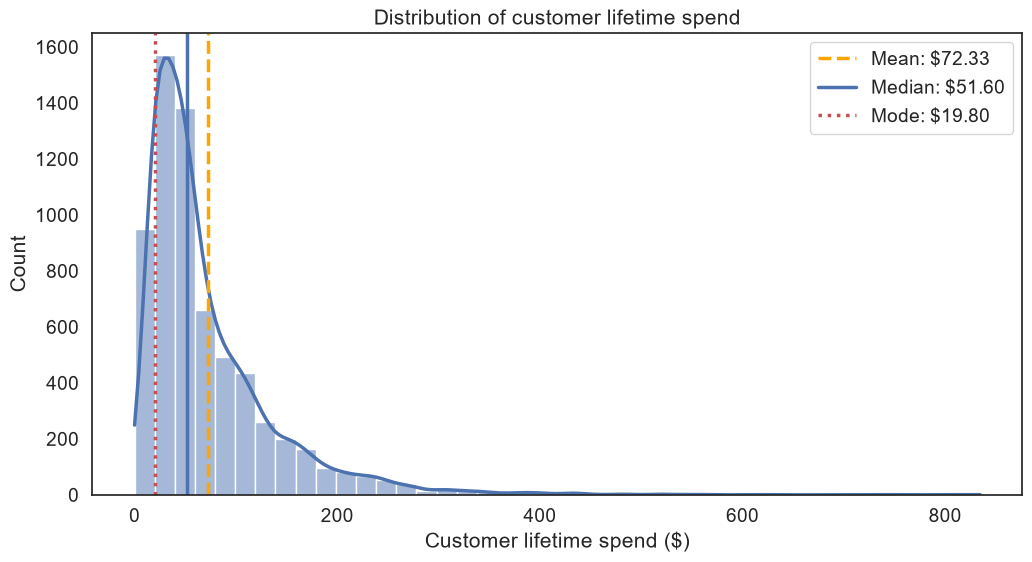

In [23]:
# Distribution of lifetime spend with measures of central tendency
ax = sns.histplot(data=cust, x='customer_total_spent', binwidth=20, kde=True)

ax.axvline(mean_clv, color='orange', linestyle='--', label=f"Mean: ${mean_clv:.2f}")
ax.axvline(median_clv, color='b', label=f"Median: ${median_clv:.2f}")
ax.axvline(modal_clv, color='r', linestyle=':', label=f"Mode: ${modal_clv:.2f}")
ax.set(title="Distribution of customer lifetime spend",
       xlabel="Customer lifetime spend ($)")
ax.legend()
plt.show()

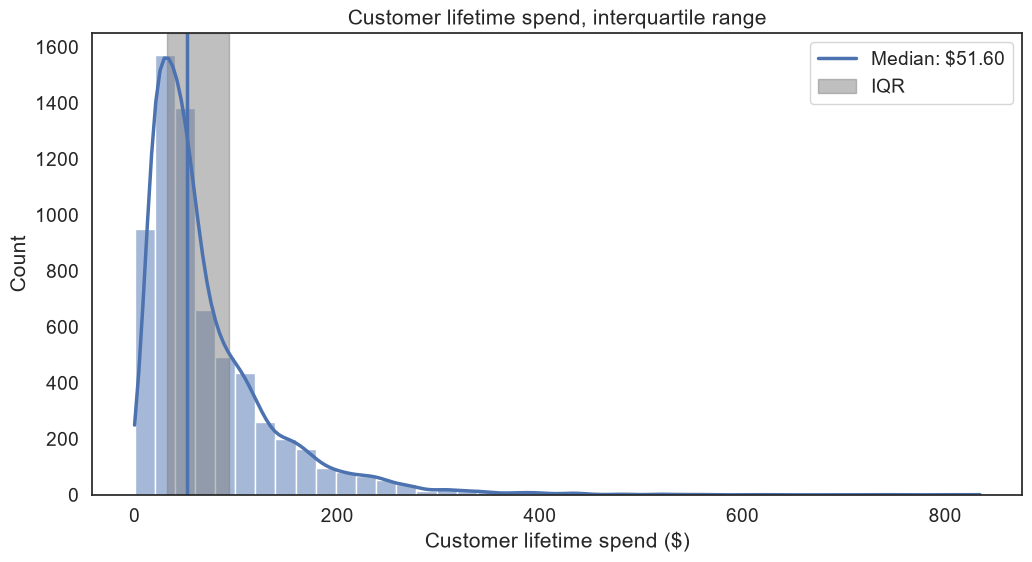

In [24]:
# The same distribution with the interquartile range shaded
quartiles = cust['customer_total_spent'].describe()

ax = sns.histplot(data=cust, x='customer_total_spent', binwidth=20, kde=True)
ax.axvline(median_clv, color='b', label=f"Median: ${median_clv:.2f}")
ax.axvspan(quartiles['25%'], quartiles['75%'], color='gray', alpha=0.5, label="IQR")
ax.set(title="Customer lifetime spend, interquartile range",
       xlabel="Customer lifetime spend ($)")
ax.legend()
plt.show()

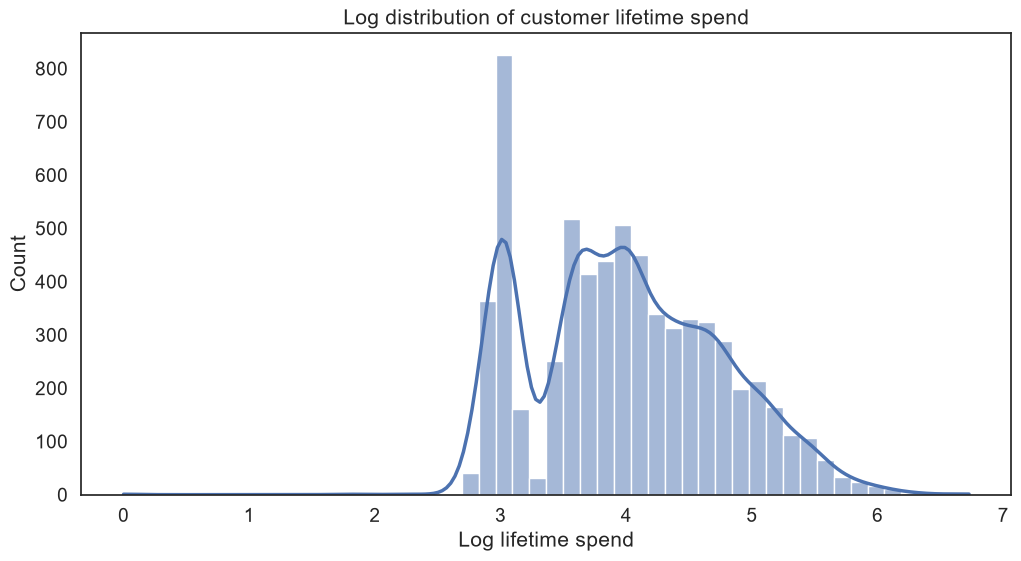

In [25]:
# Log scale, to show the shape of the distribution more clearly
sns.histplot(np.log1p(cust['customer_total_spent']), bins=50, kde=True)
plt.title("Log distribution of customer lifetime spend")
plt.xlabel("Log lifetime spend")
plt.show()

### 2.5.2 Purchase frequency

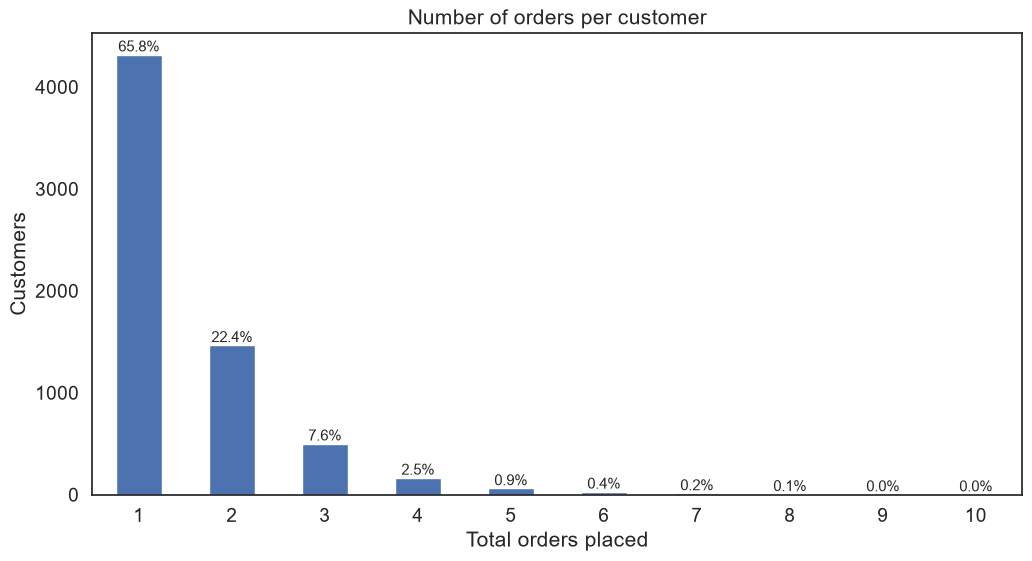

                       Customers  Share %
customer_total_orders                    
1                           4317     65.8
2                           1466     22.4
3                            500      7.6
4                            165      2.5
5                             61      0.9
6                             28      0.4
7                             12      0.2
8                              4      0.1
9                              2      0.0
10                             1      0.0


In [26]:
# Number of orders per customer
order_counts = cust['customer_total_orders'].value_counts().sort_index()
order_share = (order_counts / order_counts.sum() * 100).round(1)

ax = order_counts.plot(kind='bar', color=sns.color_palette()[0])
for i, (count, share) in enumerate(zip(order_counts, order_share)):
    ax.text(i, count, f"{share}%", ha='center', va='bottom', fontsize=11)

plt.title("Number of orders per customer")
plt.xlabel("Total orders placed")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()

print(pd.DataFrame({'Customers': order_counts, 'Share %': order_share}).to_string())

The distribution is dominated by a single bar: 65.8% of customers place exactly one order and never
return. A further 22.4% stop at two. Beyond that the base thins out very quickly — only about 4% of
customers reach a fourth purchase, and fewer than 50 customers in total reach six or more.

This shape tells Rooster where the opportunity is. The largest single gain available is not in
extending the loyalty of the small group of frequent buyers, but in converting first-time buyers
into second-time buyers.

### 2.5.3 Time to second order

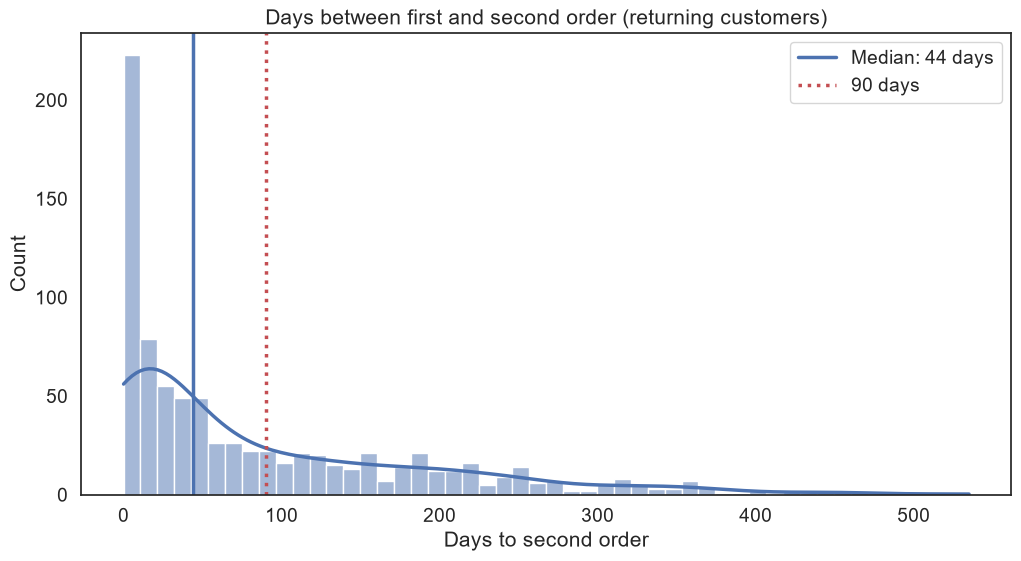

In [27]:
# Distribution of the gap between the first and second order
ax = sns.histplot(days_to_second_order, bins=50, kde=True)
ax.axvline(days_to_second_order.median(), color='b',
           label=f"Median: {days_to_second_order.median():.0f} days")
ax.axvline(90, color='r', linestyle=':', label="90 days")
ax.set(title="Days between first and second order (returning customers)",
       xlabel="Days to second order")
ax.legend()
plt.show()

The gap is concentrated early: the median returning customer comes back within 44 days, and a
quarter return within 9 days. The window in which a first-time buyer can realistically be converted
is short, which matters for how any retention campaign would be timed.

### 2.5.4 Average order value

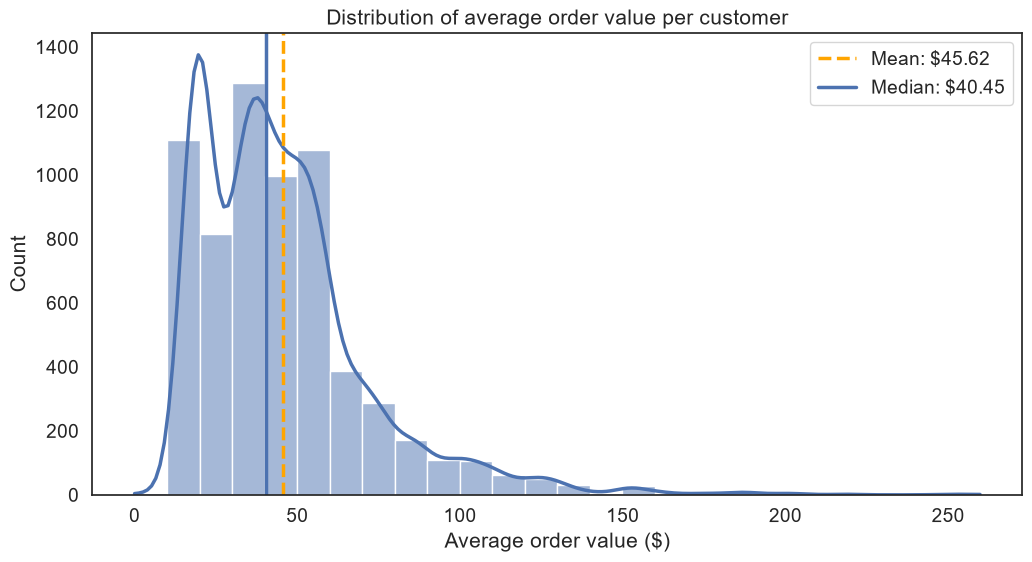

In [28]:
# Distribution of average order value
mean_aov = cust['avg_order_value'].mean()
median_aov = cust['avg_order_value'].median()

ax = sns.histplot(data=cust, x='avg_order_value', binwidth=10, kde=True)
ax.axvline(mean_aov, color='orange', linestyle='--', label=f"Mean: ${mean_aov:.2f}")
ax.axvline(median_aov, color='b', label=f"Median: ${median_aov:.2f}")
ax.set(title="Distribution of average order value per customer",
       xlabel="Average order value ($)")
ax.legend()
plt.show()

## 2.6 Current State of Retention and Value

This section quantifies the size of the retention problem and the value at stake.

### 2.6.1 Repeat versus one-time customers

In [29]:
# Compare repeat and one-time customers on the key value measures
retention_profile = cust.groupby('is_repeat').agg(
    customers=('customer_email', 'size'),
    avg_orders=('customer_total_orders', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean'),
    median_lifetime_spend=('customer_total_spent', 'median'),
    avg_order_value=('avg_order_value', 'mean'),
    total_revenue=('customer_total_spent', 'sum')
).round(2)

retention_profile.index = ['One-time customer', 'Repeat customer']
retention_profile['share_of_customers'] = (
    retention_profile['customers'] / retention_profile['customers'].sum()
).round(3)
retention_profile['share_of_revenue'] = (
    retention_profile['total_revenue'] / retention_profile['total_revenue'].sum()
).round(3)

retention_profile.T

,One-time customer,Repeat customer
customers,4317.000,2239.000
avg_orders,1.000,2.550
avg_lifetime_spend,43.020,128.840
median_lifetime_spend,37.300,108.800
avg_order_value,43.020,50.610
total_revenue,185728.600,288476.290
share_of_customers,0.658,0.342
share_of_revenue,0.392,0.608


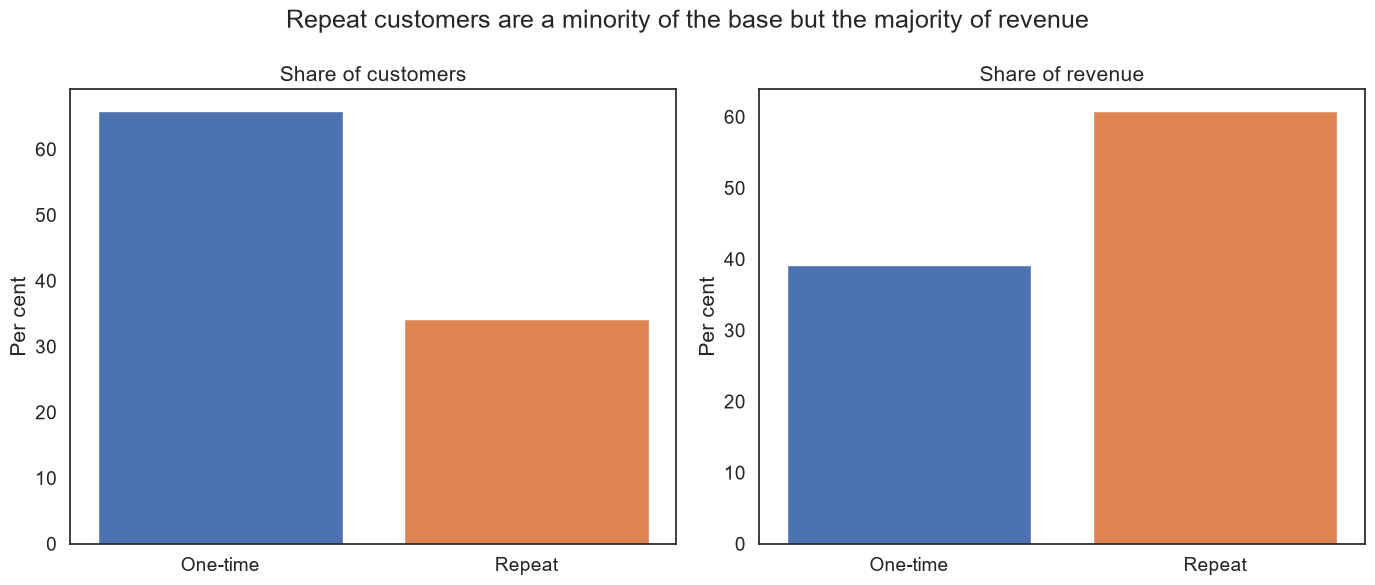

In [30]:
# Visualise the gap between the two groups
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

group_labels = ['One-time', 'Repeat']

axes[0].bar(group_labels, retention_profile['share_of_customers'] * 100,
            color=[sns.color_palette()[0], sns.color_palette()[1]])
axes[0].set_title("Share of customers")
axes[0].set_ylabel("Per cent")

axes[1].bar(group_labels, retention_profile['share_of_revenue'] * 100,
            color=[sns.color_palette()[0], sns.color_palette()[1]])
axes[1].set_title("Share of revenue")
axes[1].set_ylabel("Per cent")

plt.suptitle("Repeat customers are a minority of the base but the majority of revenue")
plt.tight_layout()
plt.show()

### 2.6.2 Revenue concentration

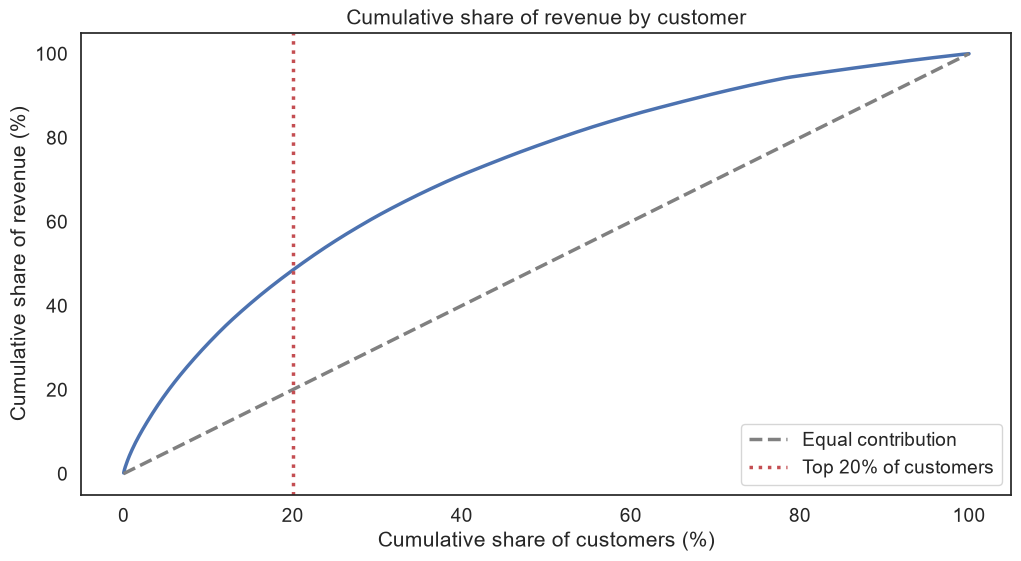

Top 10% of customers account for 31.0% of revenue
Top 20% of customers account for 48.5% of revenue
Top 50% of customers account for 78.9% of revenue


In [31]:
# How concentrated is revenue across the customer base?
spend_sorted = cust['customer_total_spent'].sort_values(ascending=False).reset_index(drop=True)
cumulative_share = spend_sorted.cumsum() / spend_sorted.sum()
customer_share = (spend_sorted.index + 1) / len(spend_sorted)

plt.plot(customer_share * 100, cumulative_share * 100)
plt.plot([0, 100], [0, 100], linestyle='--', color='gray', label="Equal contribution")
plt.axvline(20, color='r', linestyle=':', label="Top 20% of customers")
plt.title("Cumulative share of revenue by customer")
plt.xlabel("Cumulative share of customers (%)")
plt.ylabel("Cumulative share of revenue (%)")
plt.legend()
plt.show()

for pct in [0.10, 0.20, 0.50]:
    idx = int(pct * len(spend_sorted))
    print(f"Top {pct:.0%} of customers account for "
          f"{cumulative_share.iloc[idx]:.1%} of revenue")

In [32]:
# Value decile table
cust['value_decile'] = pd.qcut(
    cust['customer_total_spent'].rank(method='first', ascending=False),
    10,
    labels=[f"D{i}" for i in range(1, 11)]
)

decile_table = cust.groupby('value_decile', observed=True).agg(
    customers=('customer_email', 'size'),
    avg_lifetime_spend=('customer_total_spent', 'mean'),
    revenue=('customer_total_spent', 'sum'),
    repeat_rate=('is_repeat', 'mean'),
    avg_orders=('customer_total_orders', 'mean')
).round(2)

decile_table['share_of_revenue'] = (
    decile_table['revenue'] / decile_table['revenue'].sum()
).round(3)

decile_table

,customers,avg_lifetime_spend,revenue,repeat_rate,avg_orders,share_of_revenue
value_decile,,,,,,
D1,656,224.20,147071.93,0.95,3.20,0.310
D2,656,126.18,82774.92,0.82,2.21,0.175
D3,655,93.31,61115.97,0.69,1.82,0.129
D4,656,70.65,46348.31,0.51,1.57,0.098
D5,655,55.86,36588.13,0.15,1.18,0.077
D6,656,46.78,30688.12,0.07,1.07,0.065
D7,655,37.88,24810.25,0.18,1.18,0.052
D8,656,30.41,19951.56,0.05,1.05,0.042
D9,655,20.31,13306.16,0.00,1.00,0.028


The top decile of customers contributes 31% of revenue, and its repeat rate is far above the base
rate. Value and retention move together, which supports treating them as one problem rather than two.

### 2.6.3 Acquisition cohorts

Customers are grouped by the month of their first order. Because repeat rate is a Layer 1 measure,
it can be calculated for every cohort without the coverage problem identified in section 2.2.

In [33]:
# Repeat rate by acquisition cohort (Layer 1 - complete)
cohort_summary = cust.groupby('cohort_month').agg(
    customers=('customer_email', 'size'),
    repeat_rate=('is_repeat', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean'),
    avg_observation_days=('observation_days', 'mean')
).round(3)

# Only show cohorts with a reasonable number of customers
cohort_summary = cohort_summary[cohort_summary['customers'] >= 30]
cohort_summary.tail(12)

,customers,repeat_rate,avg_lifetime_spend,avg_observation_days
cohort_month,,,,
2024-07-01,321,0.439,85.679,349.667
2024-08-01,321,0.427,85.741,318.555
2024-09-01,282,0.454,89.862,288.801
2024-10-01,341,0.384,79.125,258.994
2024-11-01,581,0.286,72.883,225.346
2024-12-01,971,0.229,64.885,200.844
2025-01-01,148,0.331,60.488,165.514
2025-02-01,319,0.348,66.297,135.467
2025-03-01,183,0.295,66.511,108.388


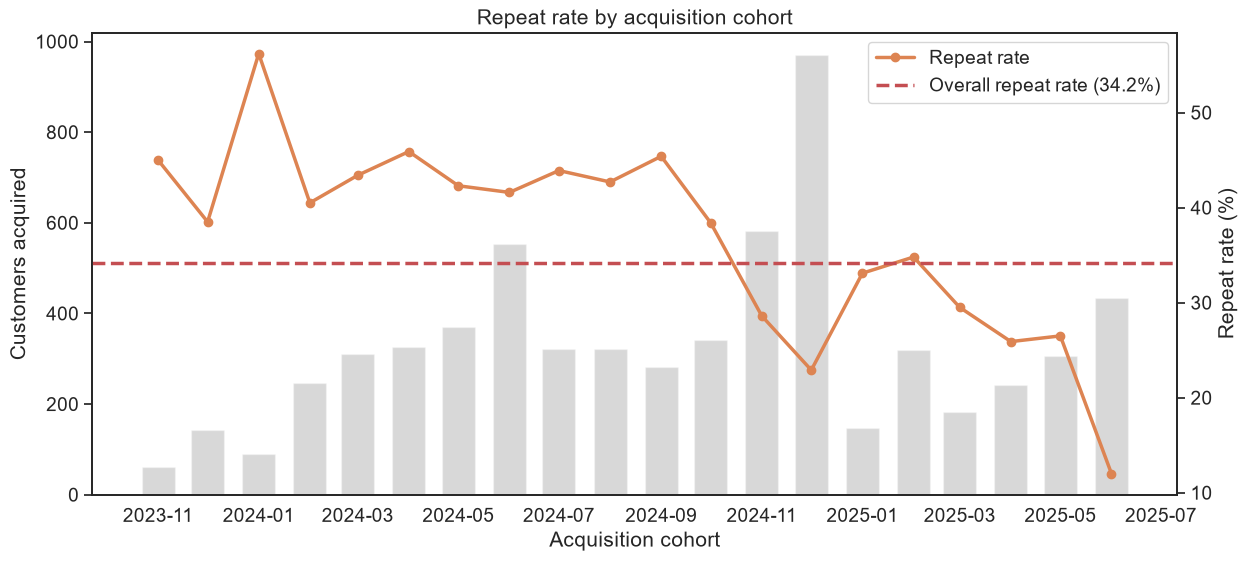

In [34]:
# Plot repeat rate by cohort against the maturity of that cohort
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(cohort_summary.index, cohort_summary['customers'],
        width=20, alpha=0.3, color='gray', label="Customers acquired")
ax1.set_ylabel("Customers acquired")
ax1.set_xlabel("Acquisition cohort")

ax2 = ax1.twinx()
ax2.plot(cohort_summary.index, cohort_summary['repeat_rate'] * 100,
         marker='o', color=sns.color_palette()[1], label="Repeat rate")
ax2.axhline(repeat_rate * 100, color='r', linestyle='--',
            label=f"Overall repeat rate ({repeat_rate:.1%})")
ax2.set_ylabel("Repeat rate (%)")

ax1.set_title("Repeat rate by acquisition cohort")
ax2.legend(loc='upper right')
plt.show()

The decline in repeat rate across the most recent cohorts is expected rather than alarming: those
customers have had less time to return. The right-censoring correction in section 2.11 separates the
genuine trend from this artefact.

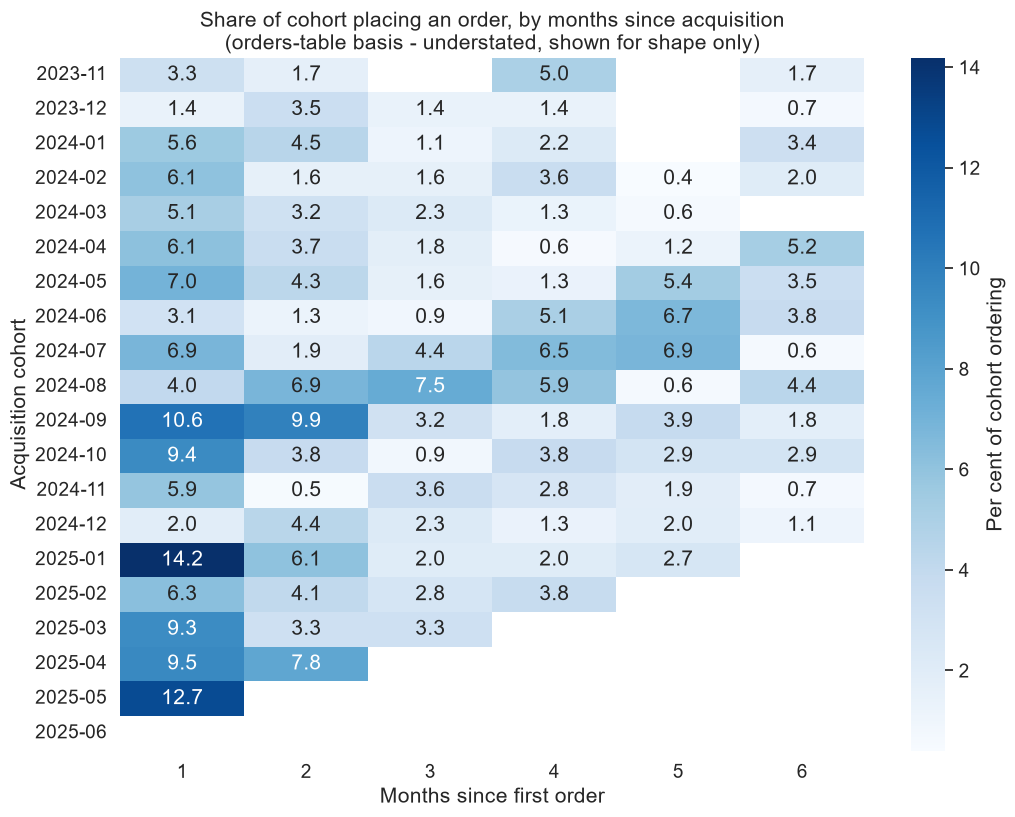

In [35]:
# Cohort retention matrix.
# Note: this is built from the orders table and is therefore understated for the reasons
# set out in section 2.2. It is included to show the SHAPE of the retention curve over time,
# not to read absolute retention rates from.
cohort_orders = orders[['customer_email', 'order_date']].merge(
    cust[['customer_email', 'cohort_month']], on='customer_email', how='left'
)
cohort_orders['order_month'] = cohort_orders['order_date'].dt.to_period('M').dt.to_timestamp()
cohort_orders['months_since_acquisition'] = (
    (cohort_orders['order_month'].dt.year - cohort_orders['cohort_month'].dt.year) * 12
    + (cohort_orders['order_month'].dt.month - cohort_orders['cohort_month'].dt.month)
)

cohort_counts = (
    cohort_orders
    .groupby(['cohort_month', 'months_since_acquisition'])['customer_email']
    .nunique()
    .unstack()
)
cohort_sizes = cust.groupby('cohort_month')['customer_email'].size()
cohort_retention = cohort_counts.div(cohort_sizes, axis=0)

# Restrict to months 1-6 after acquisition, and to cohorts of reasonable size
cohort_retention = cohort_retention.loc[
    cohort_sizes[cohort_sizes >= 30].index, 1:6
]
cohort_retention.index = cohort_retention.index.strftime('%Y-%m')

plt.figure(figsize=(12, 9))
sns.heatmap(cohort_retention * 100, annot=True, fmt=".1f", cmap="Blues",
            cbar_kws={'label': 'Per cent of cohort ordering'})
plt.title("Share of cohort placing an order, by months since acquisition\n"
          "(orders-table basis - understated, shown for shape only)")
plt.xlabel("Months since first order")
plt.ylabel("Acquisition cohort")
plt.show()

The heatmap shows repeat activity collapsing immediately after acquisition and staying flat at a low
level thereafter. There is no month in which a cohort recovers. Whatever Rooster does about
retention needs to happen in the weeks after the first order, not months later.

## 2.7 Segmentation

This section looks for meaningful differences between groups of customers. Segments drawn from
Layer 1 variables (channel, coupon use, cohort) give unbiased retention rates. Segments that depend
on first-order detail are Layer 2 and are marked accordingly.

### 2.7.1 Acquisition channel

In [36]:
# Retention and value by acquisition channel (Layer 1 - unbiased)
channel_summary = cust.groupby('acquisition_channel').agg(
    customers=('customer_email', 'size'),
    repeat_rate=('is_repeat', 'mean'),
    avg_orders=('customer_total_orders', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    total_revenue=('customer_total_spent', 'sum')
).sort_values('avg_lifetime_spend', ascending=False).round(3)

channel_summary

,customers,repeat_rate,avg_orders,avg_lifetime_spend,avg_order_value,total_revenue
acquisition_channel,,,,,,
Newsletter,356,0.374,1.593,79.666,47.675,28360.93
Google,1361,0.345,1.525,75.505,48.774,102762.33
Shopping comparison,134,0.403,1.649,75.272,43.721,10086.50
Referral,677,0.393,1.625,74.590,43.543,50497.42
Direct,1417,0.325,1.495,74.509,48.118,105579.45
Facebook,1325,0.347,1.534,68.540,43.098,90815.24
Unknown,1122,0.315,1.501,67.456,42.835,75686.14
Instagram,164,0.256,1.396,63.518,42.764,10416.88


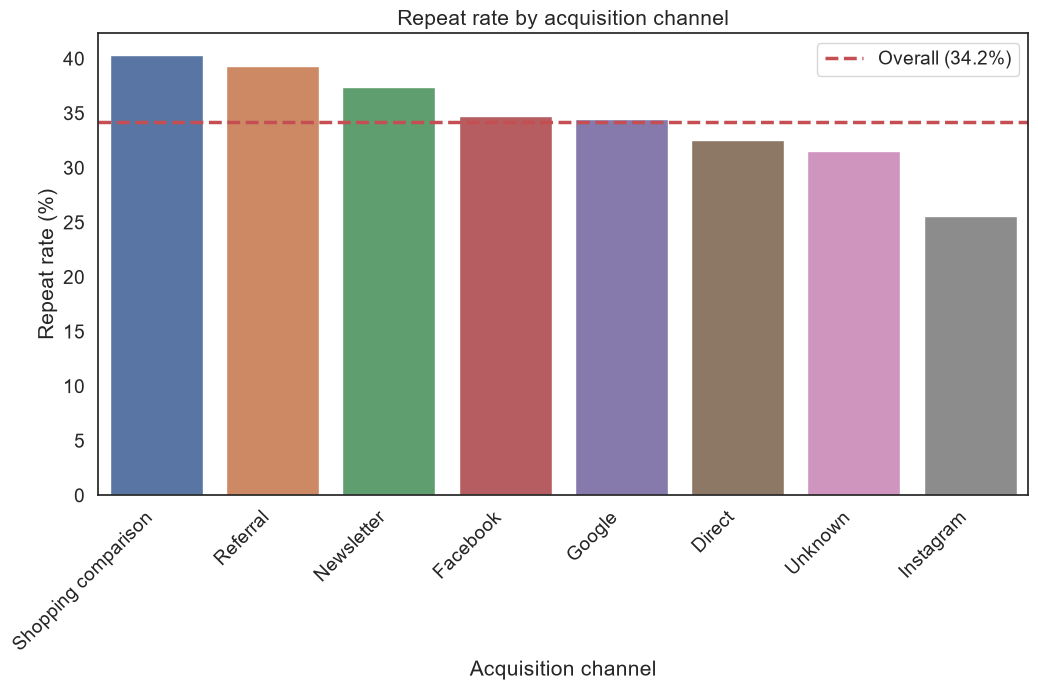

In [37]:
# Repeat rate by channel
channel_plot = channel_summary.sort_values('repeat_rate', ascending=False)

ax = sns.barplot(x=channel_plot.index, y=channel_plot['repeat_rate'] * 100,
                 hue=channel_plot.index, legend=False)
ax.axhline(repeat_rate * 100, color='r', linestyle='--',
           label=f"Overall ({repeat_rate:.1%})")
ax.set(title="Repeat rate by acquisition channel",
       xlabel="Acquisition channel", ylabel="Repeat rate (%)")
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.show()

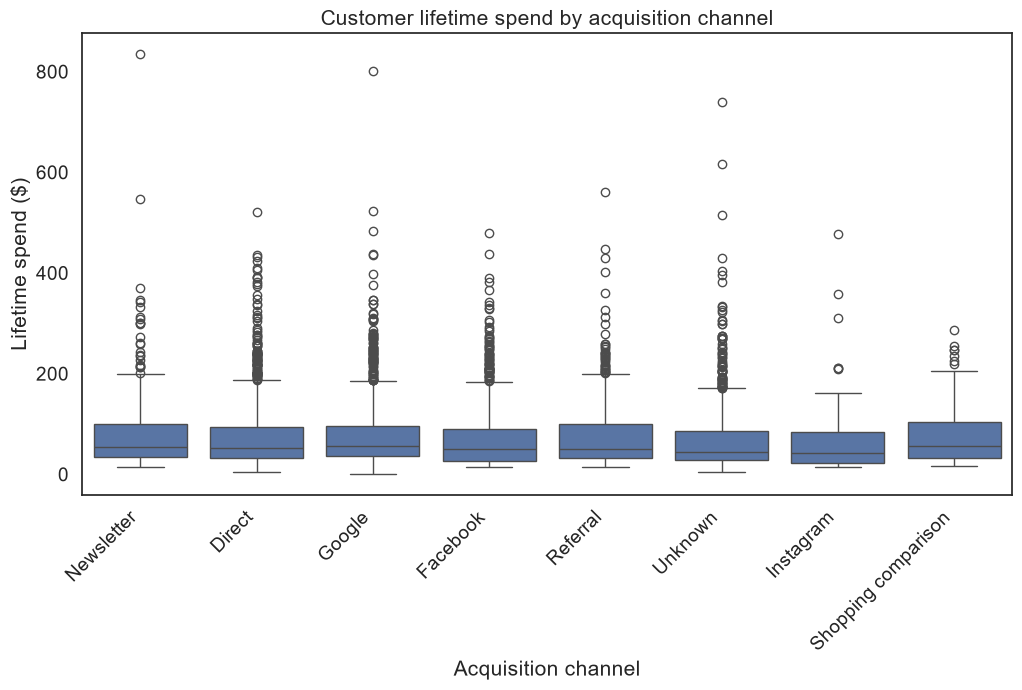

In [38]:
# Lifetime spend distribution by channel
main_channels = channel_summary[channel_summary['customers'] >= 100].index

sns.boxplot(
    data=cust[cust['acquisition_channel'].isin(main_channels)],
    x='acquisition_channel', y='customer_total_spent'
)
plt.title("Customer lifetime spend by acquisition channel")
plt.xlabel("Acquisition channel")
plt.ylabel("Lifetime spend ($)")
plt.xticks(rotation=45, ha='right')
plt.show()

Channel differences exist but are modest in size. Across the four largest channels the repeat rate
spans about seven percentage points, from Direct at 32.5% to Google at 34.5%, with Referral at 39.3%
and Newsletter at 37.4% above them. Instagram is the weakest at 25.6%, but on only 164 customers.
Average lifetime spend follows a similar ordering, ranging from $63.52 to $79.67.

This matters for how Rooster should read the result. Channel is a real signal but not a decisive
one: reallocating acquisition spend towards the better-retaining channels would help at the margin,
but it will not by itself move a 34% repeat rate. It is also worth noting that 17% of customers have
no recorded channel, which limits how confidently any channel conclusion can be drawn.

### 2.7.2 Coupon use on the first order

In [39]:
# Retention and value by whether a coupon was used on the first order (Layer 1 - unbiased)
coupon_summary = cust.groupby('used_coupon_first_order').agg(
    customers=('customer_email', 'size'),
    repeat_rate=('is_repeat', 'mean'),
    avg_orders=('customer_total_orders', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean'),
    avg_order_value=('avg_order_value', 'mean')
).round(3)

coupon_summary.index = ['No coupon on first order', 'Coupon on first order']
coupon_summary

,customers,repeat_rate,avg_orders,avg_lifetime_spend,avg_order_value
No coupon on first order,3561,0.210,1.276,58.359,44.446
Coupon on first order,2995,0.498,1.830,88.944,47.005


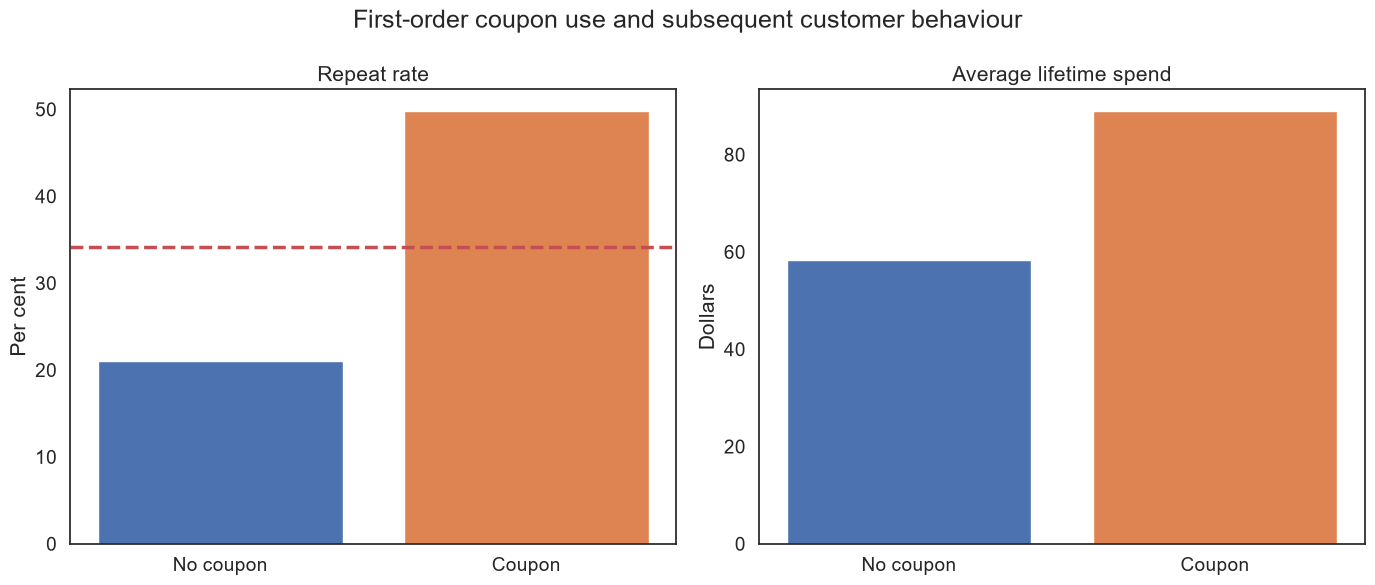

In [40]:
# Visualise the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = ['No coupon', 'Coupon']

axes[0].bar(labels, coupon_summary['repeat_rate'] * 100,
            color=[sns.color_palette()[0], sns.color_palette()[1]])
axes[0].axhline(repeat_rate * 100, color='r', linestyle='--')
axes[0].set_title("Repeat rate")
axes[0].set_ylabel("Per cent")

axes[1].bar(labels, coupon_summary['avg_lifetime_spend'],
            color=[sns.color_palette()[0], sns.color_palette()[1]])
axes[1].set_title("Average lifetime spend")
axes[1].set_ylabel("Dollars")

plt.suptitle("First-order coupon use and subsequent customer behaviour")
plt.tight_layout()
plt.show()

In [41]:
# Which coupon codes are associated with the strongest retention?
coupon_codes = cust[cust['used_coupon_first_order'] == 1].groupby('first_order_coupon_code').agg(
    customers=('customer_email', 'size'),
    repeat_rate=('is_repeat', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean')
).round(3)

coupon_codes = coupon_codes[coupon_codes['customers'] >= 50].sort_values(
    'repeat_rate', ascending=False
)
coupon_codes

,customers,repeat_rate,avg_lifetime_spend
first_order_coupon_code,,,
ROOSTER15,705,0.573,94.135
CHICKADEE20,94,0.553,100.901
ROOSTER5,1002,0.511,96.739
ROOSTER10,463,0.464,82.880
ROOSTER20,545,0.415,73.653
CYBER15,118,0.398,71.751


This is the largest single difference found in the data. Customers who used a coupon on their first
order return at **49.8%**, against **21.0%** for customers who did not — and their average lifetime
spend is roughly 50% higher ($88.94 against $58.36).

The breakdown by code is also informative: `ROOSTER15` (57.3%) and `ROOSTER5` (51.1%) retain better
than `ROOSTER20` (41.5%), the deepest of the standard codes. The relationship between discount depth
and retention is not monotonic, which is examined further in the next section.

Two cautions belong with this finding. First, it is an association, not a causal effect: coupon
codes are issued through specific marketing channels, so the coupon flag partly encodes which
campaign the customer came from. Second, the discount itself reduces margin, so a higher repeat rate
does not automatically mean higher profit. Both points are worth putting to the modelling stage and
to Rooster as questions rather than conclusions.

### 2.7.3 Discount depth on the first order (Layer 2)

Whether a coupon was used is a Layer 1 variable. *How deep* the resulting discount was is only
visible in the orders table, so this analysis is restricted to the 88.4% of customers whose first
order is in the extract. The repeat rate within this population is 25.5%, and comparisons should be
read against that baseline rather than the 34.2% headline.

In [42]:
# Group first orders into discount bands
layer2 = cust[cust['layer2_available']].copy()

layer2['discount_band'] = pd.cut(
    layer2['first_order_discount_pc'],
    bins=[-0.001, 0.0001, 0.05, 0.10, 0.15, 1.0],
    labels=['No discount', '0-5%', '5-10%', '10-15%', '15%+']
)

discount_summary = layer2.groupby('discount_band', observed=True).agg(
    customers=('customer_email', 'size'),
    repeat_rate=('is_repeat', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean'),
    avg_first_order_value=('first_order_value', 'mean')
).round(3)

discount_summary

,customers,repeat_rate,avg_lifetime_spend,avg_first_order_value
discount_band,,,,
No discount,3764,0.252,63.675,41.923
0-5%,236,0.335,64.653,35.919
5-10%,669,0.333,73.937,44.862
10-15%,227,0.220,60.095,45.262
15%+,896,0.199,56.702,43.031


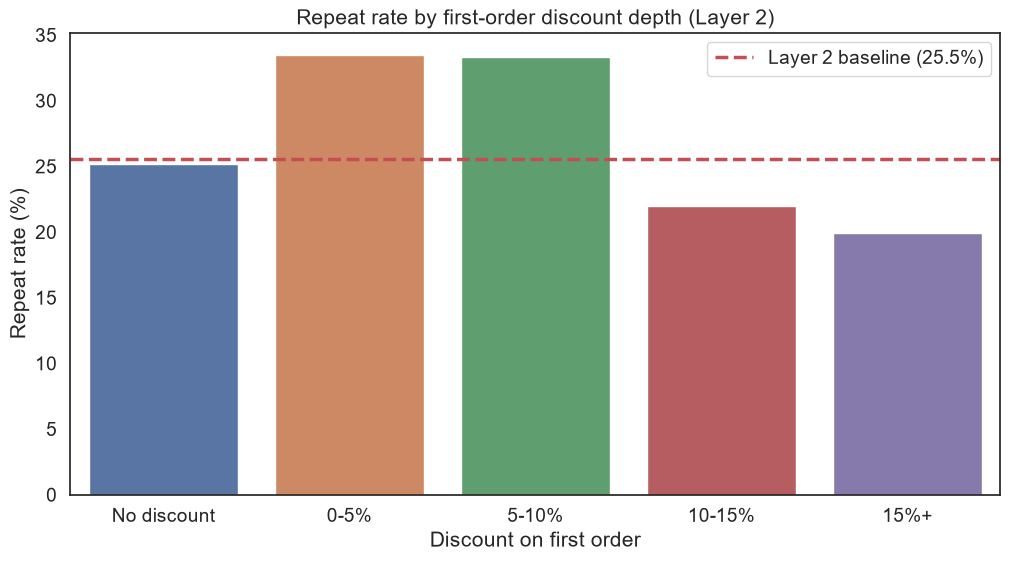

In [43]:
ax = sns.barplot(x=discount_summary.index, y=discount_summary['repeat_rate'] * 100,
                 hue=discount_summary.index, legend=False)
ax.axhline(layer2['is_repeat'].mean() * 100, color='r', linestyle='--',
           label=f"Layer 2 baseline ({layer2['is_repeat'].mean():.1%})")
ax.set(title="Repeat rate by first-order discount depth (Layer 2)",
       xlabel="Discount on first order", ylabel="Repeat rate (%)")
ax.legend()
plt.show()

Repeat rate peaks in the shallow discount bands — 33.5% at 0-5% and 33.3% at 5-10% — and then falls
away, reaching 19.9% for first orders discounted by more than 15%, which is *below* the no-discount
group at 25.2%.

A modest incentive is associated with a customer who comes back; a deep one is associated with a
customer who does not. The most plausible reading is that heavy discounts attract deal-seeking buyers
who do not convert to full price, but the pattern is also partly a coupon-code effect (the deepest
codes are concentrated in particular campaigns), so it should be treated as a question for Rooster
rather than a settled finding. It has a direct implication for the discount strategy the company is
separately trying to optimise, and it is a good candidate for a controlled test.

### 2.7.4 Product range purchased on the first order (Layer 2)

In [44]:
# Retention by the product range that dominated the first order
range_summary = layer2.groupby('first_order_range').agg(
    customers=('customer_email', 'size'),
    repeat_rate=('is_repeat', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean'),
    avg_first_order_value=('first_order_value', 'mean')
).sort_values('repeat_rate', ascending=False).round(3)

range_summary

,customers,repeat_rate,avg_lifetime_spend,avg_first_order_value
first_order_range,,,,
Underwear for Adam,3213,0.270,49.847,29.127
Value pack,1847,0.264,86.502,60.642
Underwear for Eve,717,0.170,66.776,53.826
Gift voucher,20,0.100,53.148,47.892


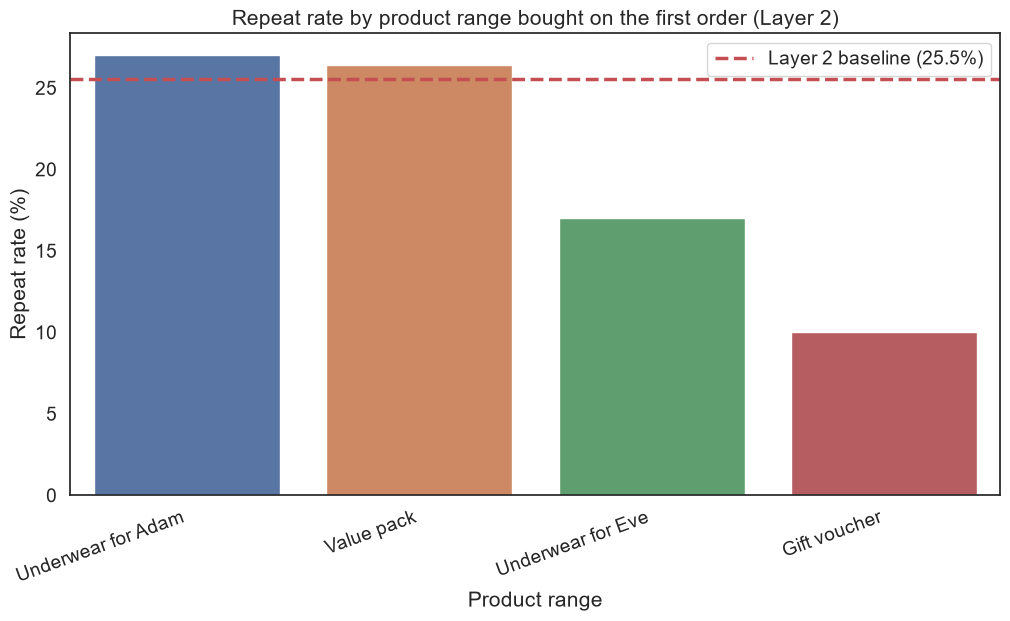

In [45]:
ax = sns.barplot(x=range_summary.index, y=range_summary['repeat_rate'] * 100,
                 hue=range_summary.index, legend=False)
ax.axhline(layer2['is_repeat'].mean() * 100, color='r', linestyle='--',
           label=f"Layer 2 baseline ({layer2['is_repeat'].mean():.1%})")
ax.set(title="Repeat rate by product range bought on the first order (Layer 2)",
       xlabel="Product range", ylabel="Repeat rate (%)")
plt.xticks(rotation=20, ha='right')
ax.legend()
plt.show()

Customers who entered through the women's range (*Underwear for Eve*) return at 17.0%, against 27.0%
for the men's range (*Underwear for Adam*) and 26.4% for value packs — a gap of roughly ten
percentage points within the Layer 2 population.

Rooster is separately planning a product range expansion for women. This finding suggests that the
existing women's range is not yet converting first-time buyers into repeat buyers at the same rate
as the men's range, and that understanding why should come before, or at least alongside, expanding
it. The women's range is also smaller in the catalogue (88 of 381 product variants), so assortment
depth is one possible explanation worth testing.

### 2.7.5 Basket size on the first order (Layer 2)

In [46]:
# Does a bigger first basket predict a returning customer?
layer2['first_order_size_band'] = pd.cut(
    layer2['first_order_units'],
    bins=[0, 1, 2, 3, 5, 100],
    labels=['1 unit', '2 units', '3 units', '4-5 units', '6+ units']
)

basket_summary = layer2.groupby('first_order_size_band', observed=True).agg(
    customers=('customer_email', 'size'),
    repeat_rate=('is_repeat', 'mean'),
    avg_first_order_value=('first_order_value', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean')
).round(3)

basket_summary

,customers,repeat_rate,avg_first_order_value,avg_lifetime_spend
first_order_size_band,,,,
1 unit,1909,0.261,19.394,38.623
2 units,1281,0.260,34.472,53.906
3 units,1171,0.320,46.867,76.959
4-5 units,982,0.197,60.948,78.573
6+ units,454,0.176,108.434,129.525


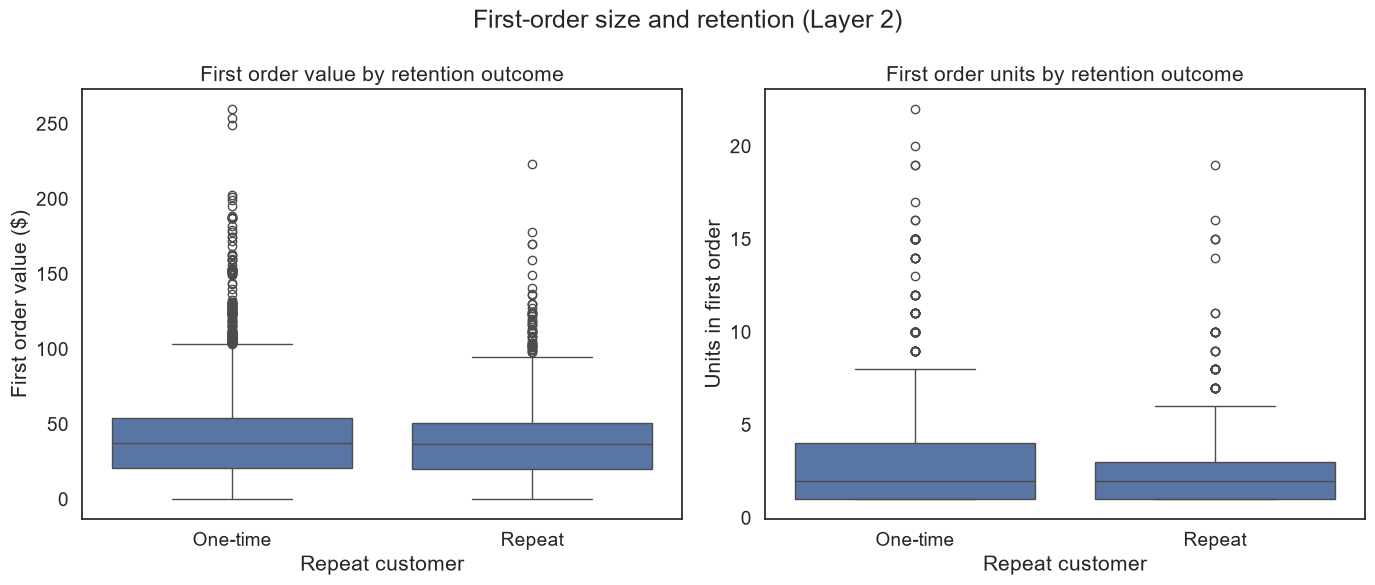

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=layer2, x='is_repeat', y='first_order_value', ax=axes[0])
axes[0].set(title="First order value by retention outcome",
            xlabel="Repeat customer", ylabel="First order value ($)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['One-time', 'Repeat'])

sns.boxplot(data=layer2, x='is_repeat', y='first_order_units', ax=axes[1])
axes[1].set(title="First order units by retention outcome",
            xlabel="Repeat customer", ylabel="Units in first order")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['One-time', 'Repeat'])

plt.suptitle("First-order size and retention (Layer 2)")
plt.tight_layout()
plt.show()

The relationship runs in the opposite direction to what might be expected. Customers who return
spent slightly *less* on their first order ($40.26 against $42.98) and bought fewer units (2.57
against 2.84).

The banded view shows the pattern is not linear. Repeat rate is flat at around 26% for one and two
unit orders, peaks at 32.0% for three-unit orders, and then falls sharply to 17.6% for orders of six
or more units. Three units looks like the point at which a customer has engaged with the range
without stocking up.

A plausible reading is that large first orders are stock-up purchases: the customer buys several
multi-packs at once and then has no reason to come back for months. This is a hypothesis rather than
a conclusion, and the effect size is small (Cohen's d = -0.11), but it is directly testable and is a
good candidate for the modelling stage, where first-order size can be assessed alongside the other
variables rather than on its own.

### 2.7.6 Region, gender and fulfilment (Layer 2)

In [48]:
# Retention by billing region
region_summary = layer2.groupby('first_order_region').agg(
    customers=('customer_email', 'size'),
    repeat_rate=('is_repeat', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean')
).round(3)

region_summary = region_summary[region_summary['customers'] >= 100].sort_values(
    'repeat_rate', ascending=False
)
region_summary

,customers,repeat_rate,avg_lifetime_spend
first_order_region,,,
South Australia,516,0.283,62.249
New Zealand,668,0.271,66.900
Western Australia,450,0.269,65.273
Victoria,749,0.267,63.528
Australian Capital Territory,591,0.259,62.798
Queensland,520,0.256,64.149
Northern Territory,365,0.255,60.171
Tasmania,527,0.250,60.023
New South Wales,763,0.248,62.237


In [49]:
# Retention by recorded gender on the first order.
# 'u' and 'Unknown' are both unrecorded values and are grouped for this comparison.
layer2['first_order_gender_grouped'] = layer2['first_order_gender'].replace(
    {'u': 'Unknown'}
)

gender_summary = layer2.groupby('first_order_gender_grouped').agg(
    customers=('customer_email', 'size'),
    repeat_rate=('is_repeat', 'mean'),
    avg_lifetime_spend=('customer_total_spent', 'mean')
).round(3)

gender_summary

,customers,repeat_rate,avg_lifetime_spend
first_order_gender_grouped,,,
Unknown,148,0.250,62.380
f,3594,0.242,58.891
m,2055,0.279,72.010


Regional differences are small: the main Australian states and New Zealand sit within four
percentage points of one another (24.8% to 28.3%). The exception is the group with no recorded
region, which retains at 13.1% — almost certainly a data-quality artefact of incomplete billing
records rather than a genuine customer segment, and a reason not to read too much into the region
variable.

Recorded gender shows a small but statistically detectable gap: male-billed first orders retain at
27.9% against 24.2% for female-billed. This is consistent with the product range finding in section
2.7.4 and points to the same underlying issue rather than being independent evidence. Neither region
nor gender looks like a useful lever on its own, but both are cheap to include as controls in the
model.

## 2.8 Relationships Between Variables

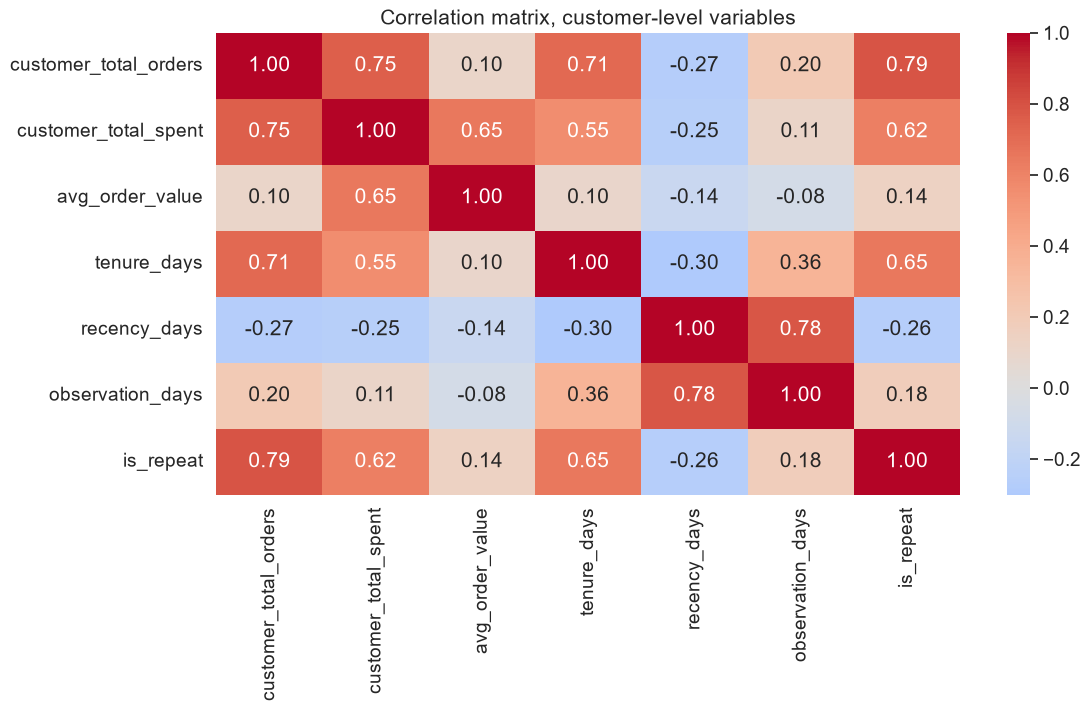

In [50]:
# Correlation between the numeric customer variables
numeric_cols = [
    'customer_total_orders',
    'customer_total_spent',
    'avg_order_value',
    'tenure_days',
    'recency_days',
    'observation_days',
    'is_repeat'
]

corr = cust[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation matrix, customer-level variables")
plt.show()

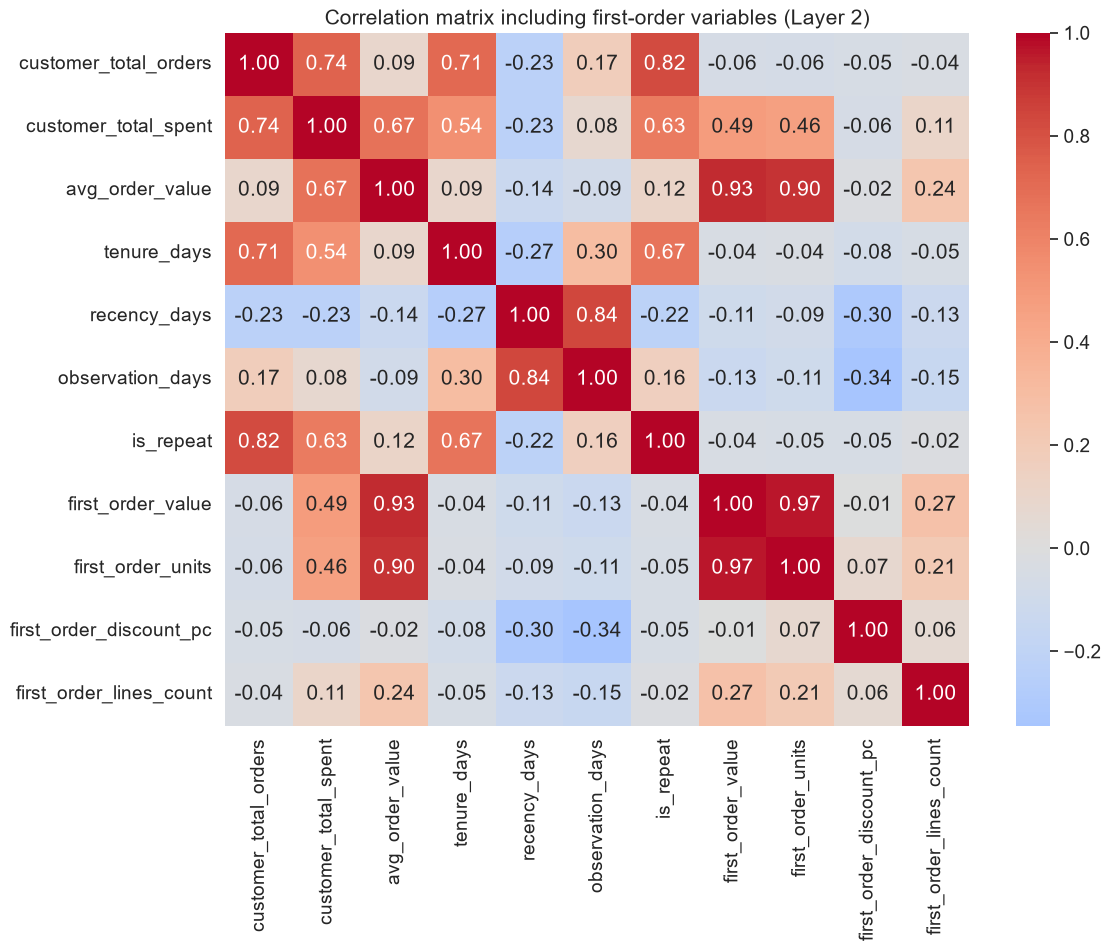

In [51]:
# Correlation including the Layer 2 first-order variables
layer2_numeric = numeric_cols + [
    'first_order_value',
    'first_order_units',
    'first_order_discount_pc',
    'first_order_lines_count'
]

corr_layer2 = layer2[layer2_numeric].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_layer2, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation matrix including first-order variables (Layer 2)")
plt.show()

Order count and average order value both correlate with lifetime spend (r = 0.75 and r = 0.65), but
they behave very differently with respect to retention. Order count correlates with repeat status at
r = 0.79; average order value correlates with it at only r = 0.14. The two are also almost
independent of one another (r = 0.10) — customers who buy often are not the customers who buy big.

For Rooster this is the clearest statement of the problem. Basket size and purchase frequency are
two separate levers, and only one of them is a retention lever. Persuading a customer to come back a
second time raises lifetime value *and* is what distinguishes the high-value part of the base;
persuading them to add another item to the order they are already placing raises lifetime value but
does nothing for retention, and the analysis in section 2.7.5 suggests it may even work against it.

`observation_days` correlates with `is_repeat` at r = 0.18, which is the right-censoring effect
appearing in the data exactly as anticipated in section 2.2.4. It is an artefact of when the customer
happened to be acquired, not a business signal, and must be excluded from the model.

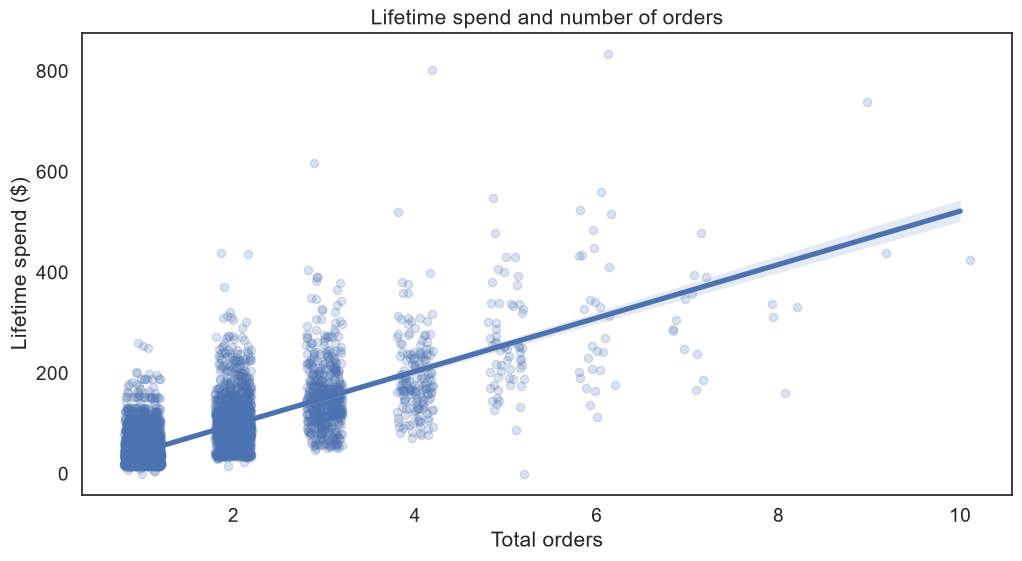

In [52]:
# Relationship between order frequency and lifetime spend
sns.regplot(data=cust, x='customer_total_orders', y='customer_total_spent',
            x_jitter=0.2, scatter_kws={'alpha': 0.2})
plt.title("Lifetime spend and number of orders")
plt.xlabel("Total orders")
plt.ylabel("Lifetime spend ($)")
plt.show()

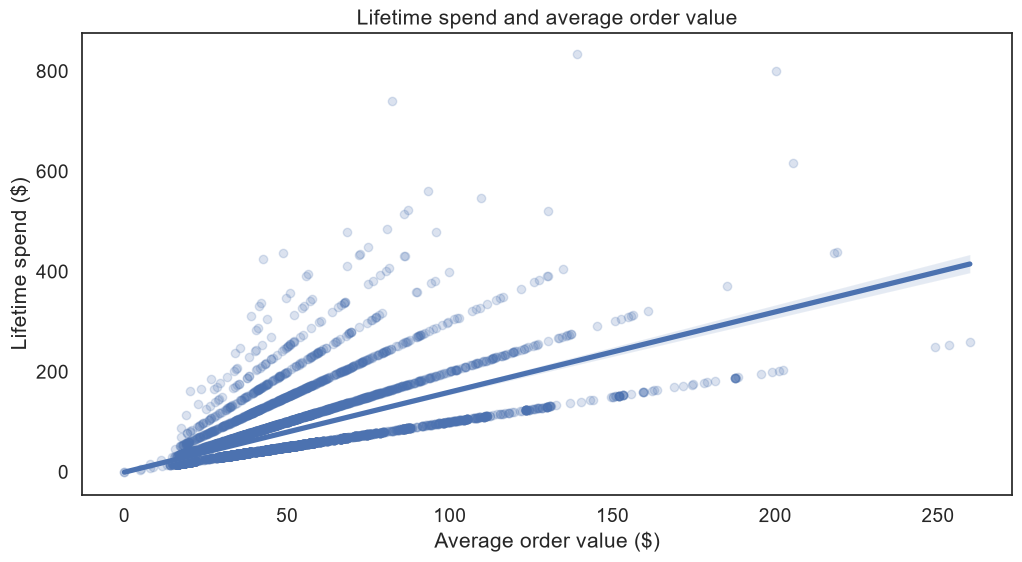

In [53]:
# Relationship between average order value and lifetime spend
sns.regplot(data=cust, x='avg_order_value', y='customer_total_spent',
            scatter_kws={'alpha': 0.2})
plt.title("Lifetime spend and average order value")
plt.xlabel("Average order value ($)")
plt.ylabel("Lifetime spend ($)")
plt.show()

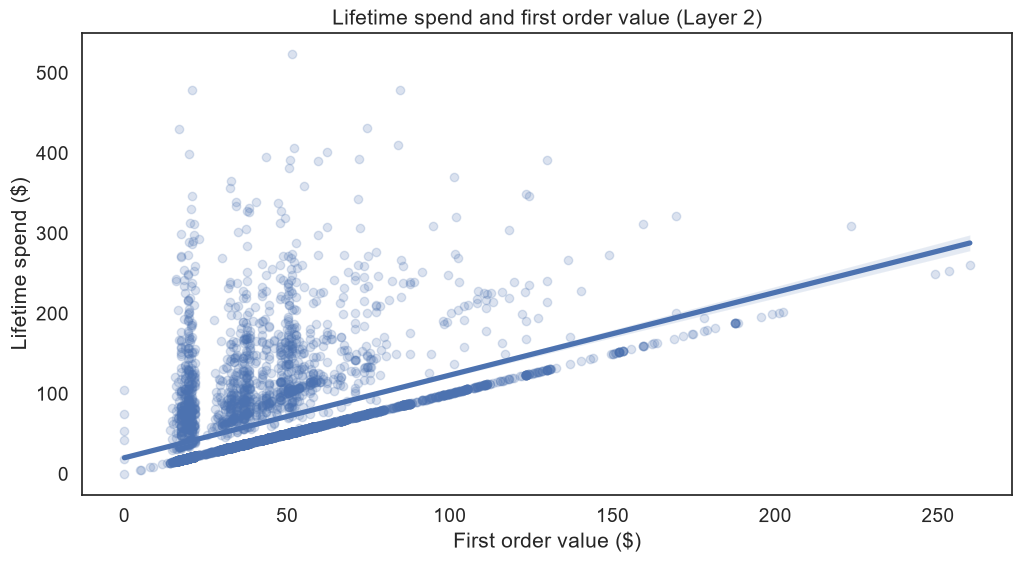

In [54]:
# Relationship between first order value and lifetime spend (Layer 2)
sns.regplot(data=layer2, x='first_order_value', y='customer_total_spent',
            scatter_kws={'alpha': 0.2})
plt.title("Lifetime spend and first order value (Layer 2)")
plt.xlabel("First order value ($)")
plt.ylabel("Lifetime spend ($)")
plt.show()

## 2.9 Statistical Testing of Group Differences

The segments above show differences in retention and value. This section tests whether those
differences are large enough to be distinguished from sampling variation, so that the modelling
notebook has an evidence-based starting point for feature selection.

Independent sample t-tests are used for continuous outcomes; chi-square tests of independence are
used for categorical predictors of the binary retention outcome.

### 2.9.1 Lifetime spend: repeat versus one-time customers

In [55]:
# Sample data for two independent groups
group_a = cust.loc[cust['is_repeat'] == 1, 'customer_total_spent']
group_b = cust.loc[cust['is_repeat'] == 0, 'customer_total_spent']

# Create a CompareMeans object
cm = sms.CompareMeans(sms.DescrStatsW(group_a), sms.DescrStatsW(group_b))

# Print individual group metrics
print(f"Group A (n={len(group_a)}) Mean (repeat customer): {group_a.mean():.4f}")
print(f"Group B (n={len(group_b)}) Mean (one-time customer) : {group_b.mean():.4f}")
print(f"Mean Diff:    {group_a.mean() - group_b.mean():.4f}\n")

# Print the full summary table
print(cm.summary(use_t=True))

Group A (n=2239) Mean (repeat customer): 128.8416
Group B (n=4317) Mean (one-time customer) : 43.0226
Mean Diff:    85.8190

                          Test for equality of means                          
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
subset #1     85.8190      1.334     64.331      0.000      83.204      88.434


### 2.9.2 Lifetime spend: coupon used on first order or not

In [56]:
group_a = cust.loc[cust['used_coupon_first_order'] == 1, 'customer_total_spent']
group_b = cust.loc[cust['used_coupon_first_order'] == 0, 'customer_total_spent']

cm = sms.CompareMeans(sms.DescrStatsW(group_a), sms.DescrStatsW(group_b))

print(f"Group A (n={len(group_a)}) Mean (coupon on first order): {group_a.mean():.4f}")
print(f"Group B (n={len(group_b)}) Mean (no coupon on first order) : {group_b.mean():.4f}")
print(f"Mean Diff:    {group_a.mean() - group_b.mean():.4f}\n")

print(cm.summary(use_t=True))

Group A (n=2995) Mean (coupon on first order): 88.9440
Group B (n=3561) Mean (no coupon on first order) : 58.3594
Mean Diff:    30.5846

                          Test for equality of means                          
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
subset #1     30.5846      1.578     19.388      0.000      27.492      33.677


### 2.9.3 First order value: repeat versus one-time customers (Layer 2)

In [57]:
group_a = layer2.loc[layer2['is_repeat'] == 1, 'first_order_value']
group_b = layer2.loc[layer2['is_repeat'] == 0, 'first_order_value']

cm = sms.CompareMeans(sms.DescrStatsW(group_a), sms.DescrStatsW(group_b))

print(f"Group A (n={len(group_a)}) Mean (repeat customer): {group_a.mean():.4f}")
print(f"Group B (n={len(group_b)}) Mean (one-time customer) : {group_b.mean():.4f}")
print(f"Mean Diff:    {group_a.mean() - group_b.mean():.4f}\n")

print(cm.summary(use_t=True))

Group A (n=1480) Mean (repeat customer): 40.2643
Group B (n=4317) Mean (one-time customer) : 42.9817
Mean Diff:    -2.7174

                          Test for equality of means                          
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
subset #1     -2.7174      0.792     -3.429      0.001      -4.271      -1.164


### 2.9.4 Chi-square tests for categorical predictors of retention

In [58]:
# Test whether each categorical variable is independent of the retention outcome
def chi_square_test(data, column, label, layer):

    contingency = pd.crosstab(data[column], data['is_repeat'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

    # Cramer's V as a measure of effect size
    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    return {
        'Variable': label,
        'Layer': layer,
        'n': int(n),
        'Chi-square': round(chi2, 2),
        'df': dof,
        'p-value': p_value,
        "Cramer's V": round(cramers_v, 3),
        'Significant at 0.05': p_value < 0.05
    }


chi_results = pd.DataFrame([
    chi_square_test(cust, 'acquisition_channel', 'Acquisition channel', 1),
    chi_square_test(cust, 'used_coupon_first_order', 'Coupon used on first order', 1),
    chi_square_test(layer2, 'first_order_range', 'Product range on first order', 2),
    chi_square_test(layer2, 'discount_band', 'Discount band on first order', 2),
    chi_square_test(layer2, 'first_order_size_band', 'First order basket size', 2),
    chi_square_test(layer2, 'first_order_region', 'Billing region', 2),
    chi_square_test(layer2, 'first_order_gender_grouped', 'Recorded gender', 2),
    chi_square_test(layer2, 'first_order_payment_method', 'Payment method', 2),
])

chi_results.sort_values("Cramer's V", ascending=False)

,Variable,Layer,n,Chi-square,df,p-value,Cramer's V,Significant at 0.05
1,Coupon used on first order,1,6556,600.36,1,1.400607e-132,0.303,True
4,First order basket size,2,5797,59.26,4,4.142192e-12,0.101,True
3,Discount band on first order,2,5792,45.98,4,2.480733e-09,0.089,True
2,Product range on first order,2,5797,34.38,3,1.648751e-07,0.077,True
5,Billing region,2,5797,22.73,11,1.927858e-02,0.063,True
0,Acquisition channel,1,6556,22.69,7,1.930316e-03,0.059,True
7,Payment method,2,5797,10.38,7,1.680978e-01,0.042,False
6,Recorded gender,2,5797,9.71,2,7.802125e-03,0.041,True


In [59]:
# t-tests for the continuous first-order variables against the retention outcome
def t_test_summary(data, column, label, layer):

    a = data.loc[data['is_repeat'] == 1, column].dropna()
    b = data.loc[data['is_repeat'] == 0, column].dropna()
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)

    # Cohen's d as a measure of effect size
    pooled_sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    cohens_d = (a.mean() - b.mean()) / pooled_sd

    return {
        'Variable': label,
        'Layer': layer,
        'Mean (repeat)': round(a.mean(), 2),
        'Mean (one-time)': round(b.mean(), 2),
        'Difference': round(a.mean() - b.mean(), 2),
        't': round(t_stat, 2),
        'p-value': p_value,
        "Cohen's d": round(cohens_d, 3),
        'Significant at 0.05': p_value < 0.05
    }


t_results = pd.DataFrame([
    t_test_summary(layer2, 'first_order_value', 'First order value', 2),
    t_test_summary(layer2, 'first_order_units', 'First order units', 2),
    t_test_summary(layer2, 'first_order_discount_pc', 'First order discount %', 2),
    t_test_summary(layer2, 'first_order_lines_count', 'First order line count', 2),
    t_test_summary(layer2, 'first_order_distinct_products', 'Distinct products in first order', 2),
])

t_results

,Variable,Layer,Mean (repeat),Mean (one-time),Difference,t,p-value,Cohen's d,Significant at 0.05
0,First order value,2,40.26,42.98,-2.72,-3.71,0.000213,-0.107,True
1,First order units,2,2.57,2.84,-0.28,-4.59,0.000005,-0.131,True
2,First order discount %,2,0.04,0.05,-0.01,-4.37,0.000013,-0.122,True
3,First order line count,2,1.37,1.41,-0.04,-1.83,0.068060,-0.053,False
4,Distinct products in first order,2,1.37,1.41,-0.03,-1.79,0.073151,-0.052,False


At this sample size almost everything reaches significance, so the effect size columns are the more
useful ones.

First-order coupon use is by far the strongest single predictor (Cramér's V = 0.30, p < 0.001) — an
order of magnitude ahead of anything else tested. Basket size band (V = 0.10), discount band
(V = 0.09) and product range (V = 0.08) follow at a considerable distance. Acquisition channel is
significant (p = 0.003) but weak (V = 0.06), which confirms the reading in section 2.7.1 that channel
is a marginal rather than a decisive lever. Payment method is the only variable that does not reach
significance and can be dropped.

The continuous first-order variables tell a consistent story: order value, units and discount depth
are all significantly *lower* among returning customers, but with effect sizes of Cohen's d ≈ -0.11
to -0.13 they separate the two groups only weakly on their own. Line count and distinct product count
do not reach significance at all.

For the modelling notebook this points to a model built around first-order coupon use, with product
range, discount depth, basket size and acquisition channel as supporting features. It also sets
expectations: with one strong predictor and a set of weak ones, a well-specified model should beat
the base rate meaningfully but is unlikely to achieve high accuracy, and should be evaluated on
ranking quality (ROC-AUC, lift in the top deciles) rather than on raw accuracy against a 66/34 class
split.

## 2.10 Outliers and Unusual Patterns

Extreme values are examined rather than removed. In a retention analysis the highest-spending
customers are the most valuable part of the base, so removing them would discard the behaviour the
business most wants to understand.

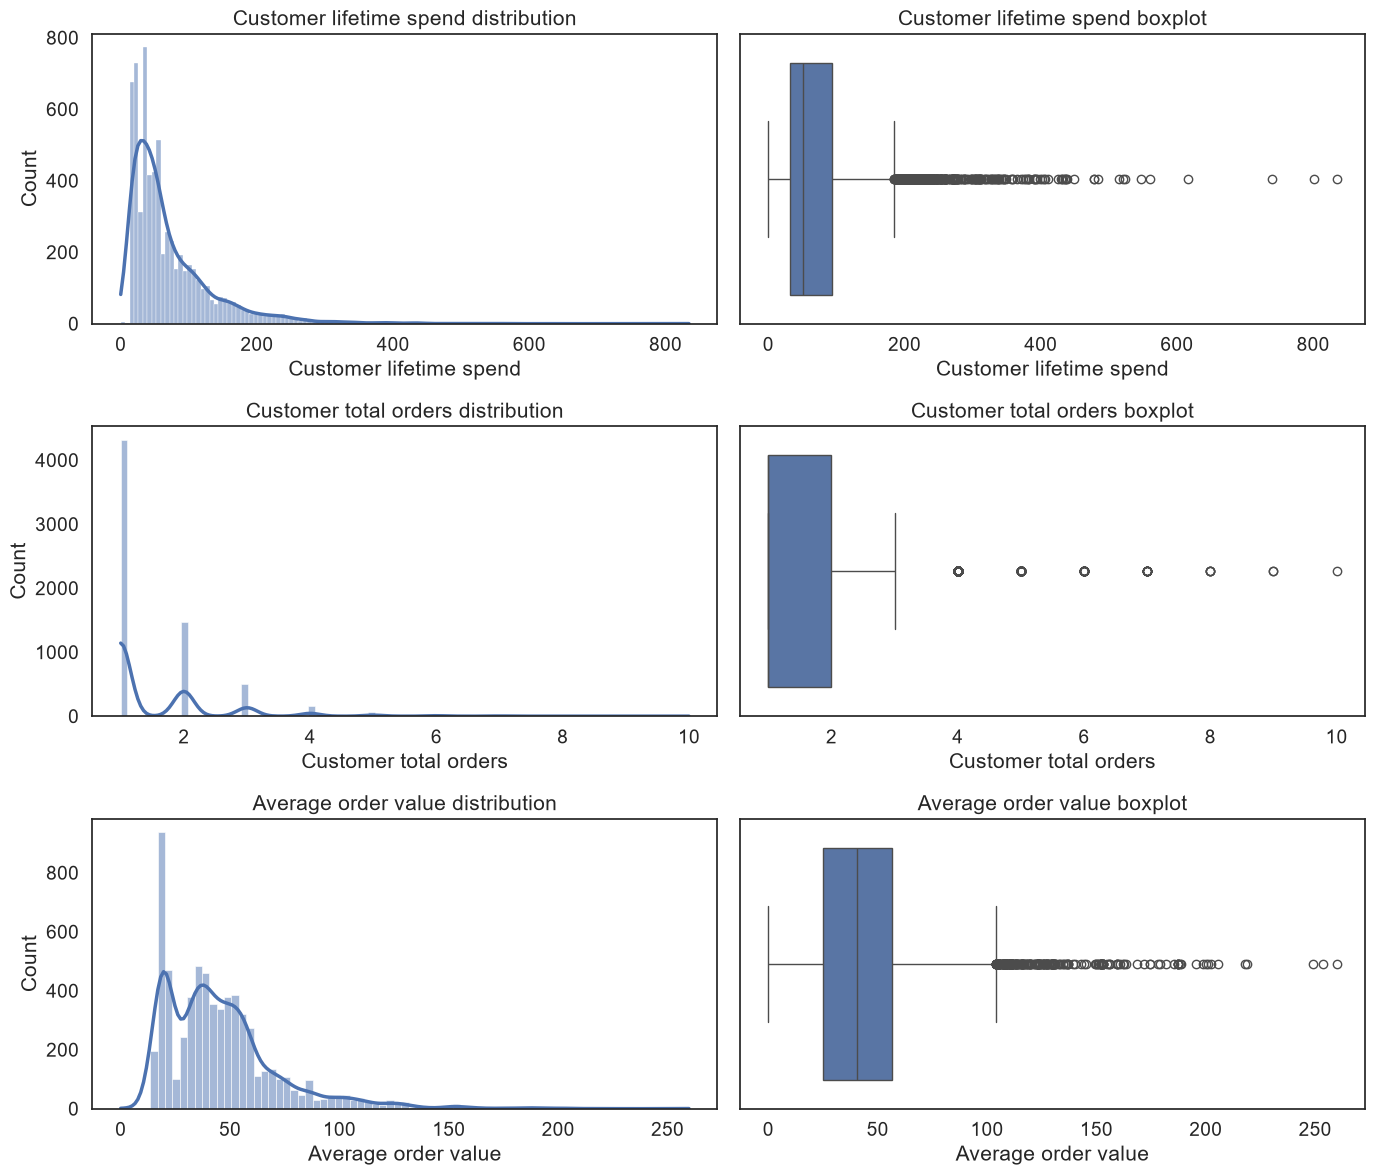

In [60]:
# Distribution and spread of the key value variables
outlier_columns = {
    'Customer lifetime spend': cust['customer_total_spent'],
    'Customer total orders': cust['customer_total_orders'],
    'Average order value': cust['avg_order_value'],
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, (label, values) in enumerate(outlier_columns.items()):
    sns.histplot(values, kde=True, ax=axes[row, 0])
    axes[row, 0].set_title(f'{label} distribution')
    axes[row, 0].set_xlabel(label)

    sns.boxplot(x=values, ax=axes[row, 1])
    axes[row, 1].set_title(f'{label} boxplot')
    axes[row, 1].set_xlabel(label)

plt.tight_layout()
plt.show()

In [61]:
# The highest-value customers
cust.nlargest(10, 'customer_total_spent')[[
    'customer_total_orders', 'customer_total_spent', 'avg_order_value',
    'acquisition_channel', 'used_coupon_first_order', 'tenure_days'
]]

,customer_total_orders,customer_total_spent,avg_order_value,acquisition_channel,used_coupon_first_order,tenure_days
5116,6,834.41,139.068333,Newsletter,1,281
5160,4,801.09,200.272500,Google,1,116
5140,9,739.36,82.151111,Unknown,1,421
2441,3,616.66,205.553333,Unknown,1,52
1569,6,560.42,93.403333,Referral,1,154
5702,5,547.33,109.466000,Newsletter,1,421
2562,6,523.66,87.276667,Google,1,172
5430,4,520.17,130.042500,Direct,1,222
5798,6,515.52,85.920000,Unknown,1,532
4627,6,484.38,80.730000,Google,1,231


In [62]:
# Customers with zero or negative lifetime spend
zero_spend = cust[cust['customer_total_spent'] <= 0]

print("Customers with lifetime spend of zero or less:", len(zero_spend))
zero_spend[['customer_total_orders', 'customer_total_spent',
            'acquisition_channel', 'first_order_coupon_code']]

Customers with lifetime spend of zero or less: 2


,customer_total_orders,customer_total_spent,acquisition_channel,first_order_coupon_code
1581,5,0.0,Google,PROMO100
2332,1,0.0,Google,VOUCHER10


In [63]:
# Orders with a total of zero or less
zero_orders = orders[orders['order_total'] <= 0]

print("Orders with a total of zero or less:", len(zero_orders))
print("\nBy coupon code:")
print(zero_orders['coupon_code'].value_counts())

Orders with a total of zero or less: 11

By coupon code:
coupon_code
VOUCHER10    3
PROMO100     2
No Coupon    2
ROOSTER20    1
ROOSTER10    1
PROMO10      1
ROOSTER5     1
Name: count, dtype: int64


Eleven orders and two customers carry a non-positive total. These are most likely fully discounted
orders, refunds or test transactions. They are too few to affect any aggregate reported here (0.14%
of orders), and they are retained rather than removed so that the customer base remains consistent
with notebook 1. They are flagged in the exported feature table so that the modelling stage can
exclude them if a regression target requires positive values.

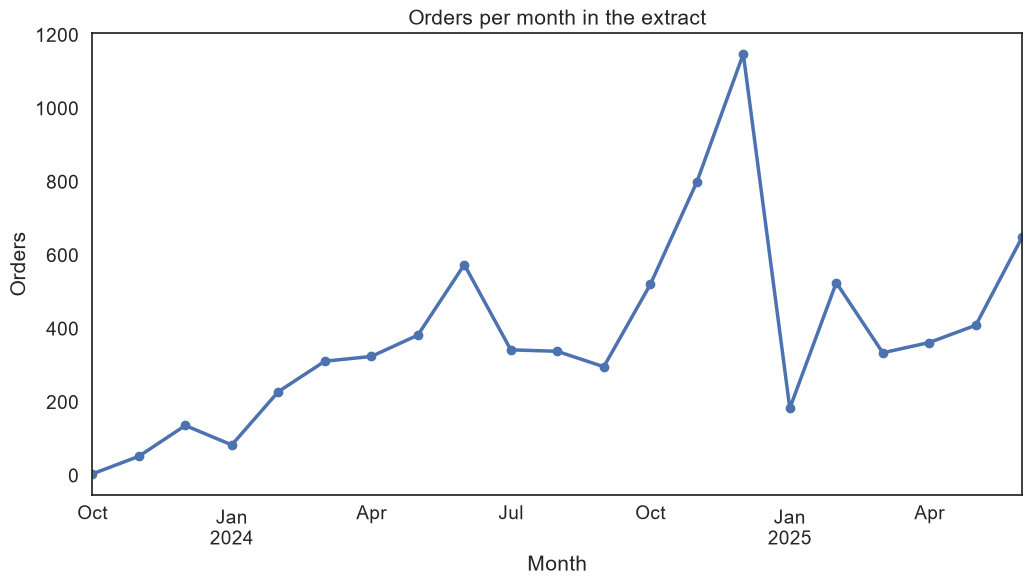

Orders by quarter:
order_date
2023-12-31     192
2024-03-31     622
2024-06-30    1280
2024-09-30     976
2024-12-31    2467
2025-03-31    1042
2025-06-30    1421
Freq: QE-DEC, dtype: int64


In [64]:
# Order volume over time - are there unusual periods in the data?
monthly_orders = orders.set_index('order_date').resample('ME').size()

ax = monthly_orders.plot(marker='o')
ax.set(title="Orders per month in the extract",
       xlabel="Month", ylabel="Orders")
plt.show()

print("Orders by quarter:")
print(orders.set_index('order_date').resample('QE').size())

Order volume is highly uneven. The December 2024 quarter carries 2,467 orders against 1,042 in the
March 2025 quarter. Some of this is genuine seasonality — Rooster sells a giftable product and runs
codes such as `CYBER15` — but the swing is large enough that part of it is likely to be an artefact
of how the extract was sampled.

This is a reason to be careful with any time-based claim in the report. Cohort-level comparisons
remain valid because each cohort is measured against its own base, but statements about revenue
growth or seasonal demand drawn from raw monthly volumes would not be safe.

In [65]:
# Imputation flags carried through from notebook 1
print("Orders with an imputed order total:",
      int(orders['order_total_was_imputed'].sum()),
      f"({orders['order_total_was_imputed'].mean():.1%})")
print("Orders with an imputed order cost: ",
      int(orders['order_cost_was_imputed'].sum()))
print("Order lines with an imputed cost:  ",
      int(orderlines['cost_was_imputed'].sum()))

Orders with an imputed order total: 500 (6.2%)
Orders with an imputed order cost:  2
Order lines with an imputed cost:   10


In [66]:
# Does excluding orders with an imputed total change the first-order findings?
imputed_first_orders = first_orders.loc[
    first_orders['order_total_was_imputed'], 'customer_email'
]

check = layer2.copy()
check['first_order_imputed'] = check['customer_email'].isin(imputed_first_orders)

print("Layer 2 customers with an imputed first-order total:",
      int(check['first_order_imputed'].sum()))
print("\nMean first order value, repeat vs one-time:")
print(check[~check['first_order_imputed']].groupby('is_repeat')['first_order_value']
      .agg(['size', 'mean']).round(2))

Layer 2 customers with an imputed first-order total: 360

Mean first order value, repeat vs one-time:
           size   mean
is_repeat             
0          4049  42.87
1          1388  40.34


Excluding the imputed order totals does not change the direction or the approximate size of the
first-order value difference, so the finding in section 2.7.5 does not depend on the imputation
decisions taken in notebook 1.

## 2.11 Sensitivity Analysis

Two limitations were identified in section 2.2: incomplete order coverage, and right-censoring of
recently acquired customers. This section quantifies how much each of them affects the conclusions.

### 2.11.1 Right-censoring

The repeat rate is recalculated on customers who have had a fair opportunity to return.

In [67]:
# Repeat rate under different maturity requirements
maturity_check = pd.DataFrame([
    {'Population': 'All customers',
     'Customers': len(cust),
     'Repeat rate': cust['is_repeat'].mean()},
    {'Population': 'Observed at least 90 days',
     'Customers': int(cust['mature_90d'].sum()),
     'Repeat rate': cust.loc[cust['mature_90d'], 'is_repeat'].mean()},
    {'Population': 'Observed at least 180 days',
     'Customers': int(cust['mature_180d'].sum()),
     'Repeat rate': cust.loc[cust['mature_180d'], 'is_repeat'].mean()},
])
maturity_check['Repeat rate'] = maturity_check['Repeat rate'].round(3)
maturity_check

,Population,Customers,Repeat rate
0,All customers,6556,0.342
1,Observed at least 90 days,5576,0.367
2,Observed at least 180 days,4928,0.372


In [68]:
# Does the channel ranking survive the censoring correction?
channel_mature = cust[cust['mature_90d']].groupby('acquisition_channel').agg(
    customers=('customer_email', 'size'),
    repeat_rate_mature=('is_repeat', 'mean')
).round(3)

channel_compare = channel_summary[['customers', 'repeat_rate']].join(
    channel_mature['repeat_rate_mature'], how='left'
)
channel_compare['difference'] = (
    channel_compare['repeat_rate_mature'] - channel_compare['repeat_rate']
).round(3)

channel_compare.sort_values('repeat_rate_mature', ascending=False)

,customers,repeat_rate,repeat_rate_mature,difference
acquisition_channel,,,,
Shopping comparison,134,0.403,0.422,0.019
Referral,677,0.393,0.403,0.010
Newsletter,356,0.374,0.395,0.021
Google,1361,0.345,0.369,0.024
Facebook,1325,0.347,0.363,0.016
Direct,1417,0.325,0.350,0.025
Unknown,1122,0.315,0.350,0.035
Instagram,164,0.256,0.339,0.083


Restricting to customers observed for at least 90 days lifts the repeat rate from 34.2% to 36.7%,
and to 37.2% at 180 days. The censoring effect is real but moderate: it shifts the level by two to
three percentage points without reversing any comparison. Every channel improves by a similar amount
and the ranking holds, with the single exception of Instagram, which gains 8.3 points on a base of
164 customers — small enough that it is more likely sampling noise than a genuine recovery.

**The headline figure reported to Rooster should be 34.2%, described as the observed rate across the
current base**, with the note that a fully matured base would sit closer to 37%. The modelling
notebook should train on the 90-day matured population (5,576 customers), which removes the censoring
without discarding much data.

### 2.11.2 Order coverage

The Layer 2 population under-represents repeat customers by construction. This check confirms that
the two populations are otherwise comparable, so that Layer 2 comparisons can be trusted.

In [69]:
# Compare the Layer 2 population against the full customer base on Layer 1 characteristics
coverage_check = pd.DataFrame({
    'All customers': [
        len(cust),
        cust['customer_total_spent'].mean(),
        cust['avg_order_value'].mean(),
        cust['used_coupon_first_order'].mean(),
    ],
    'Layer 2 population': [
        int(cust['layer2_available'].sum()),
        cust.loc[cust['layer2_available'], 'customer_total_spent'].mean(),
        cust.loc[cust['layer2_available'], 'avg_order_value'].mean(),
        cust.loc[cust['layer2_available'], 'used_coupon_first_order'].mean(),
    ]
}, index=['Customers', 'Mean lifetime spend', 'Mean order value', 'Coupon on first order']).round(3)

coverage_check

,All customers,Layer 2 population
Customers,6556.000,5797.000
Mean lifetime spend,72.331,63.631
Mean order value,45.615,44.823
Coupon on first order,0.457,0.427


In [70]:
# Channel mix is comparable between the two populations
channel_mix_check = pd.concat([
    cust['acquisition_channel'].value_counts(normalize=True),
    cust.loc[cust['layer2_available'], 'acquisition_channel'].value_counts(normalize=True)
], axis=1, keys=['All customers', 'Layer 2 population']).round(3)

channel_mix_check

,All customers,Layer 2 population
acquisition_channel,,
Direct,0.216,0.217
Google,0.208,0.208
Facebook,0.202,0.202
Unknown,0.171,0.172
Referral,0.103,0.101
Newsletter,0.054,0.053
Instagram,0.025,0.026
Shopping comparison,0.020,0.021


Channel mix is almost identical between the two populations (differences of well under one
percentage point), and average order value is close. Lifetime spend is lower in the Layer 2
population, which is the expected consequence of under-representing repeat customers rather than a
separate problem.

Layer 2 comparisons between groups are therefore sound, provided the retention *level* is always
read against the Layer 2 baseline of 25.5% rather than the headline 34.2%.

## 2.12 Potential Impact

The current state can be translated into a rough estimate of what improving retention is worth,
which gives the recommendations section a figure to work from.

This is deliberately a simple arithmetic scenario, not a forecast. It assumes only that converted
customers behave like today's repeat customers, and it makes no allowance for the cost of achieving
the conversion.

In [71]:
# What would a shift in the repeat rate be worth?
one_time_customers = int((cust['is_repeat'] == 0).sum())
avg_spend_repeat = cust.loc[cust['is_repeat'] == 1, 'customer_total_spent'].mean()
avg_spend_once = cust.loc[cust['is_repeat'] == 0, 'customer_total_spent'].mean()
value_gap = avg_spend_repeat - avg_spend_once

print(f"One-time customers in the base:        {one_time_customers:,}")
print(f"Average lifetime spend, repeat:        ${avg_spend_repeat:.2f}")
print(f"Average lifetime spend, one-time:      ${avg_spend_once:.2f}")
print(f"Value gap per converted customer:      ${value_gap:.2f}")
print()

# Scenario 1: what is one percentage point of repeat rate worth across the current base?
print("SCENARIO 1 - lifting the repeat rate across the current base")
for points in [1, 3, 5]:
    converted = n_customers * points / 100
    print(f"  +{points} percentage point(s) of repeat rate "
          f"({converted:,.0f} customers converted) "
          f"= ${converted * value_gap:,.0f} "
          f"({converted * value_gap / revenue_total:.1%} of base revenue)")

print()

# Scenario 2: what is it worth on an annual acquisition intake?
customers_last_12m = int((cust['customer_first_order_date'] >
                          ANALYSIS_CUTOFF - pd.Timedelta(days=365)).sum())
print("SCENARIO 2 - applying the same lift to one year of new customers")
print(f"  Customers acquired in the 12 months to {ANALYSIS_CUTOFF.date()}: {customers_last_12m:,}")
for points in [1, 3, 5]:
    converted = customers_last_12m * points / 100
    print(f"  +{points} percentage point(s) on that intake "
          f"({converted:,.0f} customers) = ${converted * value_gap:,.0f} per year")

One-time customers in the base:        4,317
Average lifetime spend, repeat:        $128.84
Average lifetime spend, one-time:      $43.02
Value gap per converted customer:      $85.82

SCENARIO 1 - lifting the repeat rate across the current base
  +1 percentage point(s) of repeat rate (66 customers converted) = $5,626 (1.2% of base revenue)
  +3 percentage point(s) of repeat rate (197 customers converted) = $16,879 (3.6% of base revenue)
  +5 percentage point(s) of repeat rate (328 customers converted) = $28,131 (5.9% of base revenue)

SCENARIO 2 - applying the same lift to one year of new customers
  Customers acquired in the 12 months to 2025-06-30: 4,451
  +1 percentage point(s) on that intake (45 customers) = $3,820 per year
  +3 percentage point(s) on that intake (134 customers) = $11,459 per year
  +5 percentage point(s) on that intake (223 customers) = $19,099 per year


A repeat customer is worth $85.82 more over their lifetime than a one-time customer. Lifting the
repeat rate by one percentage point across the current base of 6,556 customers is therefore worth
roughly **$5,600 in additional lifetime revenue**, or about 1.2% of the revenue the base has
generated to date. A five point lift — from 34.2% to 39.2% — would be worth around $28,000, close to
6% of base revenue.

The second scenario is the more useful one for planning, because retention work applies to customers
Rooster is going to acquire anyway. Applied to the most recent twelve months of acquisition, a five
point lift on that intake of 4,451 customers is worth roughly $19,000 per year in additional lifetime
revenue, recurring for as long as the improvement holds.

Three caveats belong with these figures. They are gross revenue, not margin, and any retention
campaign carries a cost that has to be netted off — which matters especially if the mechanism is
discounting, given the section 2.7.3 result. They assume converted customers reach the same lifetime
value as today's repeat customers, which is optimistic: customers who need an incentive to return are
probably not identical to those who return unprompted. And the base itself is an extract rather than
Rooster's whole customer file, so the dollar amounts scale with the true customer count rather than
representing the company's total opportunity. The percentages are the more transferable figures.

## 2.13 Feature Table for Predictive Modelling

The customer-level table assembled in this notebook is exported for the modelling notebook. This
avoids duplicating the measurement decisions documented above, and ensures that the model is trained
on the same definition of retention used in the descriptive analysis.

In [72]:
# Assemble the export
feature_columns = [
    # identifier
    'customer_email',

    # target variable
    'is_repeat',

    # alternative targets / outcome measures (NOT to be used as predictors)
    'customer_total_orders', 'customer_total_spent', 'avg_order_value',
    'tenure_days', 'recency_days',

    # Layer 1 predictors - available for all customers
    'acquisition_channel', 'used_coupon_first_order', 'first_order_coupon_code',
    'customer_first_order_date', 'cohort_month',

    # Layer 2 predictors - available for 88.4% of customers
    'first_order_value', 'first_order_units', 'first_order_qty',
    'first_order_discount_pc', 'first_order_lines_count',
    'first_order_distinct_products', 'first_order_n_ranges', 'first_order_range',
    'first_order_region', 'first_order_payment_method',
    'first_order_shipping_method', 'first_order_gender',

    # sampling and validity flags
    'observation_days', 'mature_90d', 'mature_180d', 'layer2_available',
]

features = cust[feature_columns].copy()

# Flag the non-positive value records identified in section 2.10
features['non_positive_spend'] = cust['customer_total_spent'] <= 0

print("Feature table:", features.shape)
features.head()

Feature table: (6556, 29)


,customer_email,is_repeat,customer_total_orders,customer_total_spent,avg_order_value,tenure_days,recency_days,acquisition_channel,used_coupon_first_order,first_order_coupon_code,customer_first_order_date,cohort_month,first_order_value,first_order_units,first_order_qty,first_order_discount_pc,first_order_lines_count,first_order_distinct_products,first_order_n_ranges,first_order_range,first_order_region,first_order_payment_method,first_order_shipping_method,first_order_gender,observation_days,mature_90d,mature_180d,layer2_available,non_positive_spend
0,eml_0002a23b87@gmail.example.net,0,1,103.89,103.89,0,327,Newsletter,1,ROOSTER5,2024-08-07,2024-08-01,103.89,7.0,3.0,0.06,3.0,3.0,2.0,Underwear for Adam,Western Australia,Cash on delivery,Courier (free),f,327,True,True,True,False
1,eml_00078d07d7@gmail.example.net,0,1,44.45,44.45,0,260,Newsletter,1,ROOSTER15,2024-10-13,2024-10-01,44.45,3.0,1.0,0.18,1.0,1.0,1.0,Value pack,South Australia,Cash on delivery,Pick-up Point,f,260,True,True,True,False
2,eml_000e7aef6e@gmail.example.net,1,2,135.00,67.50,30,77,Direct,0,No Coupon,2025-03-15,2025-03-01,67.50,4.0,1.0,0.00,1.0,1.0,1.0,Value pack,Australian Capital Territory,Online payment,Courier,m,107,True,False,True,False
3,eml_00163a8915@gmail.example.net,1,2,78.00,39.00,14,253,Google,1,ROOSTER,2024-10-06,2024-10-01,50.60,3.0,1.0,0.00,1.0,1.0,1.0,Value pack,Queensland,Online payment,Pick-up Point,m,267,True,True,True,False
4,eml_0017ce14ce@gmail.example.net,1,5,332.60,66.52,207,195,Newsletter,1,ROOSTER5,2024-05-24,2024-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,402,True,True,False,False


In [73]:
# Data dictionary to accompany the export
data_dictionary = pd.DataFrame([
    ('customer_email', 'Identifier', 'Unique customer identifier'),
    ('is_repeat', 'TARGET', 'Customer placed 2 or more orders (customer_total_orders >= 2)'),
    ('customer_total_orders', 'Outcome', 'Total orders - do not use as a predictor of is_repeat'),
    ('customer_total_spent', 'Outcome', 'Lifetime spend - alternative regression target'),
    ('avg_order_value', 'Outcome', 'Lifetime spend divided by total orders'),
    ('tenure_days', 'Outcome', 'Days between first and last order'),
    ('recency_days', 'Outcome', 'Days from last order to the analysis cut-off'),
    ('acquisition_channel', 'Predictor L1', 'Channel of first order, small categories grouped as Other'),
    ('used_coupon_first_order', 'Predictor L1', 'Coupon used on first order (strongest single predictor)'),
    ('first_order_coupon_code', 'Predictor L1', 'Coupon code used on first order'),
    ('customer_first_order_date', 'Predictor L1', 'Date of first order'),
    ('cohort_month', 'Predictor L1', 'Month of first order'),
    ('first_order_value', 'Predictor L2', 'Amount charged on the first order'),
    ('first_order_units', 'Predictor L2', 'Product units in the first order'),
    ('first_order_qty', 'Predictor L2', 'Charged quantity in the first order'),
    ('first_order_discount_pc', 'Predictor L2', 'Discount as a share of the first order subtotal'),
    ('first_order_lines_count', 'Predictor L2', 'Charged lines in the first order'),
    ('first_order_distinct_products', 'Predictor L2', 'Distinct product variants in the first order'),
    ('first_order_n_ranges', 'Predictor L2', 'Number of product ranges in the first order'),
    ('first_order_range', 'Predictor L2', 'Product range accounting for most units in the first order'),
    ('first_order_region', 'Predictor L2', 'Billing region of the first order'),
    ('first_order_payment_method', 'Predictor L2', 'Payment method used on the first order'),
    ('first_order_shipping_method', 'Predictor L2', 'Shipping method used on the first order'),
    ('first_order_gender', 'Predictor L2', 'Recorded gender on the first order billing record'),
    ('observation_days', 'Flag', 'Days from first order to cut-off - EXCLUDE from the model, it leaks the censoring'),
    ('mature_90d', 'Flag', 'TRUE if observed for at least 90 days - recommended training filter'),
    ('mature_180d', 'Flag', 'TRUE if observed for at least 180 days'),
    ('layer2_available', 'Flag', 'TRUE if the first order is present in the orders extract'),
    ('non_positive_spend', 'Flag', 'TRUE if lifetime spend is zero or negative'),
], columns=['Column', 'Role', 'Description'])

data_dictionary

,Column,Role,Description
0,customer_email,Identifier,Unique customer identifier
1,is_repeat,TARGET,Customer placed 2 or more orders (customer_tot...
2,customer_total_orders,Outcome,Total orders - do not use as a predictor of is...
3,customer_total_spent,Outcome,Lifetime spend - alternative regression target
4,avg_order_value,Outcome,Lifetime spend divided by total orders
5,tenure_days,Outcome,Days between first and last order
6,recency_days,Outcome,Days from last order to the analysis cut-off
7,acquisition_channel,Predictor L1,"Channel of first order, small categories group..."
8,used_coupon_first_order,Predictor L1,Coupon used on first order (strongest single p...
9,first_order_coupon_code,Predictor L1,Coupon code used on first order


In [74]:
# Export the feature table and the data dictionary
FEATURES_PATH = 'rooster_features.xlsx'

with pd.ExcelWriter(FEATURES_PATH, engine='openpyxl') as writer:
    features.to_excel(writer, sheet_name='customer_features', index=False)
    data_dictionary.to_excel(writer, sheet_name='data_dictionary', index=False)

print(f'Exported {FEATURES_PATH}')
print(f'  customer_features: {features.shape[0]} rows, {features.shape[1]} columns')
print(f'  data_dictionary:   {data_dictionary.shape[0]} rows')

Exported rooster_features.xlsx
  customer_features: 6556 rows, 29 columns
  data_dictionary:   29 rows


In [75]:
# Recommended modelling population, for reference in the next notebook
modelling_population = features[features['mature_90d']]

print("Recommended training population (mature_90d):", len(modelling_population))
print(f"Repeat rate in that population: {modelling_population['is_repeat'].mean():.1%}")
print(f"Of which Layer 2 features available: "
      f"{modelling_population['layer2_available'].mean():.1%}")

Recommended training population (mature_90d): 5576
Repeat rate in that population: 36.7%
Of which Layer 2 features available: 87.5%


## 2.14 Summary of Findings

**Current state.** Rooster has 6,556 customers in this extract, acquired between October 2023 and
June 2025, who have generated $474,205 in revenue. 34.2% of them have placed a second order; 65.8%
have bought once and not returned. The average customer is worth $72.33 over their lifetime, but the
median is $51.60 and the mode $19.80 — customer value is heavily right-skewed, and the top decile of
customers generates 31% of revenue.

**Retention is where the value is.** Repeat customers are a third of the base but generate 60.8% of
revenue, and are worth $128.84 each against $43.02 for a one-time customer. Order count correlates
with lifetime spend at r = 0.75 and with repeat status at r = 0.79, while average order value
correlates with repeat status at only r = 0.14. Frequency and basket size are close to independent
(r = 0.10): they are two separate levers, and only frequency is a retention lever.

**The window is short.** The median returning customer comes back within 44 days, a quarter within 9
days, and two thirds within 90. Cohort analysis shows repeat activity collapsing in the first month
after acquisition and never recovering. Any intervention has to land in the weeks after the first
order.

**Coupon use on the first order is the strongest signal in the data.** Customers who used a coupon on
their first order return at 49.8% against 21.0% for those who did not, with lifetime spend of $88.94
against $58.36 (Cramér's V = 0.30, p < 0.001). This is an order of magnitude stronger than any other
variable tested. It remains an association rather than a demonstrated causal effect — coupon codes
are distributed through particular channels, so the flag partly encodes campaign membership — and the
discount carries a margin cost this analysis cannot see.

**But discount depth works against retention.** Repeat rate peaks in the 0-10% discount bands at
around 33% and falls to 19.9% above 15%, below the 25.2% of customers who received no discount at
all. A modest incentive is associated with a returning customer; a deep one is not. This bears
directly on the discount strategy Rooster is separately trying to optimise.

**Channel differences are real but marginal.** The main channels span about seven percentage points
of repeat rate, with Referral (39.3%) and Newsletter (37.4%) ahead of Direct (32.5%) and Instagram
(25.6%). Channel is worth optimising at the margin; it will not move the headline number on its own.
17% of customers have no recorded channel, which further limits what can be concluded here.

**The women's range under-performs on retention.** Customers who entered through *Underwear for Eve*
return at 17.0% against 27.0% for the men's range and 26.4% for value packs, within the Layer 2
population. Given that Rooster is planning a women's range expansion, this warrants investigation
before the expansion rather than after it. The women's range is also the smaller assortment (88 of
381 product variants), which is one testable explanation.

**Larger first orders are associated with lower retention**, not higher. Repeat rate peaks at 32.0%
for three-unit first orders and falls to 17.6% at six or more units. The effect size is small
(Cohen's d = -0.13) but consistent, and fits an interpretation of large first orders as stock-up
purchases that delay the next one.

**What it is worth.** A repeat customer is worth $85.82 more than a one-time customer. One percentage
point of repeat rate across the current base is worth roughly $5,600 in lifetime revenue (1.2% of
base revenue); a five point lift is worth around $28,000, or roughly $19,000 per year when applied to
the most recent twelve months of acquisition. These are gross revenue figures on optimistic
assumptions and should be read as the scale of the prize rather than as a target.

**Limitations carried into the next stage.** The orders extract is missing 2,026 orders in a pattern
correlated with the retention outcome, which constrains first-order analysis to 88.4% of customers
and requires the two-layer measurement rule used throughout. Right-censoring depresses the observed
repeat rate by two to three points. Monthly order volumes are too uneven to support claims about
seasonality or growth. No cost, margin, acquisition cost or marketing spend data is available, so
nothing here speaks to profitability — which is a real constraint given that the strongest finding
involves discounting.

**Handover to modelling.** `rooster_features.xlsx` contains a customer-level table with the target
variable `is_repeat`, Layer 1 and Layer 2 predictors, and the flags needed to apply the maturity
filter. The evidence above suggests a model built around first-order coupon use, with product range,
discount depth, basket size and acquisition channel as supporting features. Two cautions: train on
the `mature_90d` population to avoid learning the censoring, and exclude `observation_days`,
`customer_total_orders`, `customer_total_spent`, `tenure_days` and `recency_days` as predictors —
they are outcomes of retention, not causes of it, and including them would leak the target.